In [1]:
import warnings
# Suppress all DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp # 'sympy' library for symbolic calculations

# # Setting the fontsize of x, y label and title of python plots globally
# import matplotlib as mpl
# # Set global font sizes
# mpl.rcParams['axes.titlesize'] = 12      # Title font size
# mpl.rcParams['axes.labelsize'] = 12      # X and Y label font size
# mpl.rcParams['xtick.labelsize'] = 10     # X tick label font size
# mpl.rcParams['ytick.labelsize'] = 10     # Y tick label font size
# mpl.rcParams['legend.fontsize'] = 8     # Legend font size
# mpl.rcParams['font.size'] = 12           # General font size (e.g. for text)
# mpl.rcParams['figure.dpi'] = 300         # higher dpi = more resolution

# # For Interactive window (zoom-in, zoom-out feature)
# # %matplotlib widget

# # Uncomment the below one high quality plots
# # plots and code are in same window
# %matplotlib inline  
# # for clear image, can be set to 'pdf/png' format also
# %config InlineBackend.figure_format = 'retina'  

In [3]:
import matplotlib as mpl
mpl.rcParams.update({
    # Figure
    "figure.figsize": (6.5, 4.5),   # single-column paper
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # Fonts
    "font.size": 12,          # base font
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.borderpad": 0.3,
    "legend.labelspacing": 0.3,
    "legend.handlelength": 1.2,
    "legend.handletextpad": 0.4,

    # Lines and markers
    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    # Axes
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # Grid (if used)
    "grid.linewidth": 0.6,
    "grid.alpha": 0.4,
})

#### Universal constants in SI units ( Global variable )

In [4]:
G = 6.67 * (1e-11)
pc = 3*(1e16)
c = 3*(1e8)

# Mass of Sun in Kg
M_sun = 1e30

#### Binary Masses

In [5]:
# BINARY MASSES

# Primary Mass (bigger BH)
mass_1 = (1e3)*M_sun
# Secondary Mass (smaller BH)
mass_2 = 10*M_sun
# Total mass
total_mass = mass_1 + mass_2

eta = mass_1*mass_2/(total_mass**2)

# ISCO distance
r_min = (6*G*mass_1)/(c**2)

# Conversion factors ( Geometrized units G = c = 1 )
t0 = r_min/c        # from ISCO distance to seconds
l0 = r_min          # from ISCO distance to meters
m0 = (c**2)*r_min/G # from ISCO distance to kg

# Binary masses in ISCO distance (bcz we write DE in geometrized units ,i.e, G = c = 1)
m1 = mass_1 / m0
m2 = mass_2 / m0
M = total_mass / m0

#### Initial orbital parameters

In [6]:
# Initial eccentricity
e_i = 5
# Initial value of semi-latus rectum (has NO meaning for hyperbolic orbit but it is related to impact prameter 'b') in ISCO distance
p_i = 100
# Initial value of omega in radians
omega_i = round(np.arccos(-1/e_i),2)
# Staring time
t_i = 0.0

# Distance between binaries and observation point
R = 10 * 1e6 * pc / l0  # in ISCO distance units

#### Hyperbolic orbit 

##### a ) Relation between impact parameter 'b' and 'p'

## <center>$ b = \frac{p}{\sqrt{e^2 - 1}}$</center>

##### b ) Relation between eccentrcity 'e' and $\omega$

## <center>$ e = - \frac{1}{\cos (\omega)}$</center>

##### c ) NOTE : The Initial value of semi-rectum should NOT exceed this limit to ensure relative velocity of binary should NOT exceed speed of light 

## <center>$ p_i \geq \frac{G m}{c^2} ( {e_i}^2 - 1) $</center>

$m = M = m_1 + m_2 $

## Perturbing forces

In [7]:
# DM Minispike gravity as perturbing force
def DM_gravity(y, f, alpha):
    r = rel_distance(y, f)
    R_dm = -FF(alpha)/(r**(alpha-1)) 
    S_dm = 0.0

    return R_dm, S_dm

# ( Relativistic DF + Accretion ) as perturbing force
def DF_accretion(y, f, alpha, combination):
    r = rel_distance(y, f)
    rhodm = rho_dm(y, f, alpha)

    rdot = r_dot(y, f, alpha, combination)
    phidot = phi_dot(y, f, alpha, combination)
    velocity = v(y, f, alpha, combination) 
    
    # Relativistic factor 
    xi_v = (1 - velocity**2)*( 1 + velocity**2 )**2
    
    R_DF = -4*(np.pi)*(m2)*(rhodm)*( I_v * xi_v )*rdot/( velocity**3 )  
    S_DF = -(4*(np.pi)*(m2)*(rhodm)*( I_v * xi_v )*phidot/(velocity**3))*r

    R_accretion = -4*(np.pi)*(m2)*(rhodm)*( lamda )*rdot/( velocity**3 )  
    S_accretion = -(4*(np.pi)*(m2)*(rhodm)*( lamda )*phidot/(velocity**3))*r

    return  R_DF + R_accretion, S_DF + S_accretion

# GW backreaction as perturbing force
def GW_backreaction(y, f, alpha, combination, val):
    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    phidot = phi_dot(y, f, alpha, combination)
    velocity = v(y, f, alpha, combination)
    m = M
    # PN terms
    A1PN = ( -3*(rdot**2)*eta/2 + velocity**2 + 3*eta*(velocity**2) - (m/r)*( 4 + 2*eta ) )
    A2PN = ( 15*(rdot**4)*eta/8 - 45*(rdot**4)*(eta**2)/8  - 9*(rdot**2)*eta*(velocity**2)/2 + 6*(rdot**2)*(eta**2)*(velocity**2) 
             + 3*eta*(velocity**4) - 4*(eta**2)*(velocity**4) + (m/r)*( -2*(rdot**2) - 25*(rdot**2)*eta 
             - 2*(rdot**2)*(eta**2) -13*eta*(velocity**2)/2 + 2*(eta**2)*(velocity**2) ) )
    A2pt5PN = (( 8*m*eta*rdot/(5*r) )*( - (17/3)*(m/r) - 3*(velocity**2) ))
    
    B1PN = ( -4*rdot + 2*rdot*eta )
    B2PN = ( 9*(rdot**3)*eta/2 + 3*(rdot**3)*(eta**2) - 15*rdot*eta*(velocity**2)/2 - 2*rdot*(eta**2)*(velocity**2)      
             + (m/r)*(  2*rdot + 41*rdot*eta/2 + 4*rdot*(eta**2) ) )
    B2pt5PN = ( 8*m*eta/(5*r) )*( 3*(m/r) + (velocity**2) )

    if val==2.5: # If val = 2.5 means we are taking only 2.5 PN radiation reaction terms
        R_gw = -(m/(r**2))*( A2pt5PN + rdot*B2pt5PN )
        S_gw = -(m/r)*B2pt5PN*phidot
        return R_gw , S_gw
    else:  # Full 1PN, 2PN, 2.5PN terms taken
        R_gw = -(m/(r**2))*( A1PN + A2PN + A2pt5PN + rdot*( B1PN + B2PN + B2pt5PN ) )
        S_gw = -(m/r)*( B1PN + B2PN + B2pt5PN )*phidot
        return R_gw , S_gw  

## Instantaneous Osculating equations for Hyperbolic orbit

## $ \frac{de}{df} \simeq   - \frac{\sin (f)}{(\cos(f))^2} \frac{d\omega}{df}$

## $ \frac{dp}{df} \simeq 2  \frac{p^3}{G m}   \frac{1}{(1 + e \cos (f))^3}  S $

## $ \frac{d\omega}{df} \simeq \frac{1}{e} \frac{p^2}{G m}  \left[ -\frac{\cos (f)}{(1 + e \cos (f))^2} R +\frac{(2 + e \cos (f))}{(1+e \cos (f))^3} \sin (f) S - e \cot (\tau ) \frac{ \sin (\omega +f)}{(1+e \cos (f))^3} W \right] $

## $ \frac{dt}{df} \simeq \sqrt{\frac{p^3}{Gm}} \cdot \frac{1}{(1 + e \cos f)^2} \left( 1 - \frac{1}{e} \cdot \frac{p^2}{Gm} \left( \frac{\cos f}{(1 + e \cos f)^2} R - \frac{2 + e \cos f}{(1 + e \cos f)^3} \sin f \, S \right) \right)   $ 

In [8]:
def DeDf_HE(y, f, alpha, combination, R, S):  
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    dedf = -( np.sin(omega) / (np.cos(omega))**2 ) * DomegaDf_HE(y, f, alpha, combination, R, S)
    return dedf


def DpDf_HE(y, f, alpha, combination, R, S):
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    dpdf = ( (2*(p**3) )/( m ) )*( 1/( (1+ (e*(np.cos(f))) )**3 ) )*S
    return dpdf
    

def DomegaDf_HE(y, f, alpha, combination, R, S):
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    domegadf = ((p**2)/( e*m ))*( -( (np.cos(f))/((1+e*(np.cos(f)) )**2 ) )*R + \
                                  ( ((np.sin(f))*(2+ e*(np.cos(f))))/((1+e*(np.cos(f)) )**3 ))*S )  
    return domegadf


def DtDf_HE(y, f, alpha, combination, R, S):
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    dtdf = ( np.sqrt( (p**3)/(m)) )*(  1 / ( (1 + (e*np.cos(f)) )**2 ) )  \
          *( 1 - ( (p**2)/(e*m) )*(  ( (np.cos(f))/ ( (1 +(e*np.cos(f)) )**2 ) )*R - \
                                         ( (2+(e*np.cos(f)) )/( (1+(e*np.cos(f)) )**3 ) )*(np.sin(f))*S  ) ) 
    return dtdf

## Hyperbolic binaries in Vacuum

#### Relative distance between binaries

## <center>$ r = \frac{p}{[ 1 + e \cos{f} ]}$</center>

where, 

$p$ = semi-latus rectum,
$e$ = eccentrcity,
$ f = (\phi - \omega) $ = true anomaly

In [9]:
# Relative distance between binaries
def rel_distance(y, f):
    e, p, omega, t = y
    return abs(p/( 1 + e*np.cos(f) ))

def r_dot(y, f, alpha, combination):
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    return np.sqrt(m/p) * e * np.sin(f)

def phi_dot(y, f, alpha, combination):
    e, p, omega, t = y
    if combination==0 or combination==1 or combination==11:
        m = M
    else:
        m = M_eff(alpha)
    return np.sqrt( (m)/(p**3) ) * ( 1 + e * np.cos(f) )**2 

# Define function for relative velocity
def v(y, f, alpha, combination):
    return np.sqrt( (r_dot(y, f, alpha, combination))**2 + ( rel_distance(y, f) * phi_dot(y, f, alpha, combination) )**2 )

# Relativistic DF factor
def xi(v):
    return (1 - v**2)*( 1 + v**2 )**2

In [10]:
# Instantaneous osculating equations considering only GW backreaction
def hyperbolic_osculating_eqn_gw_brxn(f,y,val,combination,alpha):
    R, S = GW_backreaction(y, f, alpha, combination, val)
    dedf = DeDf_HE(y, f, alpha, combination, R, S)
    dpdf = DpDf_HE(y, f, alpha, combination, R, S)
    domegadf = DomegaDf_HE(y, f, alpha, combination, R, S)
    dtdf = DtDf_HE(y, f, alpha, combination, R, S)
    return [dedf, dpdf, domegadf, dtdf]

class hyperbolic_orbit_evolution_without_DM:
    # Initial parameters
    def __init__(self, e_i, p_i, omega_i, t_i):
        self.e_i = e_i
        self.p_i = p_i
        self.omega_i = omega_i
        self.t_i = t_i
    
    # Orbit evolution considering only GW backreaction
    def hyperbolic_orbit_evolution_gw_brxn(self, val):
        # Define the event function
        def stopping_condition(f, y):
            return rel_distance(y, f) - r_min/l0  # Integration stops when distance between binaries reach ISCO

        # Make the event terminal and specify the direction
        stopping_condition.terminal = True    # ensures that the solver stops integration when the event is detected.
        stopping_condition.direction = 0      # allows the detection of zero crossings in any direction (i.e., both increasing and decreasing)

        # Coupled osculating equations
        def coupled_osculating_eqns(f,y):
            return hyperbolic_osculating_eqn_gw_brxn(f,y,val,combination=0,alpha=0)

        # Initial conditions
        initial_conditions = [self.e_i, self.p_i, self.omega_i, self.t_i]

        # Initial value of true anomaly 'f' should be [-np.arccos(-1/e_i)] to correspond binaries starts from very far apart (infinity)
        # but we have added small angle to make sure terms containing (1/(1 + e Cos(f))) doesn't blows up
        f_initial = np.arccos(-1/self.e_i + 1e-4) 

        f_span = (-f_initial, f_initial)   # True anomaly is independent variable here

        # Solve the system using solve_ivp
        solution = solve_ivp(coupled_osculating_eqns, f_span, initial_conditions, events=stopping_condition, method='RK45',
                            atol=1e-12, rtol=1e-8, max_step=0.01) # One can set max_step= accordingly

        # print(solution.success)
        # print(solution.status)
        print(solution.message)
        
        return solution.t, solution.y

In [11]:
hyperbolic_sol_GW = hyperbolic_orbit_evolution_without_DM(e_i, p_i, omega_i, t_i)

fGW, yGW = hyperbolic_sol_GW.hyperbolic_orbit_evolution_gw_brxn(val=2.5) 

The solver successfully reached the end of the integration interval.


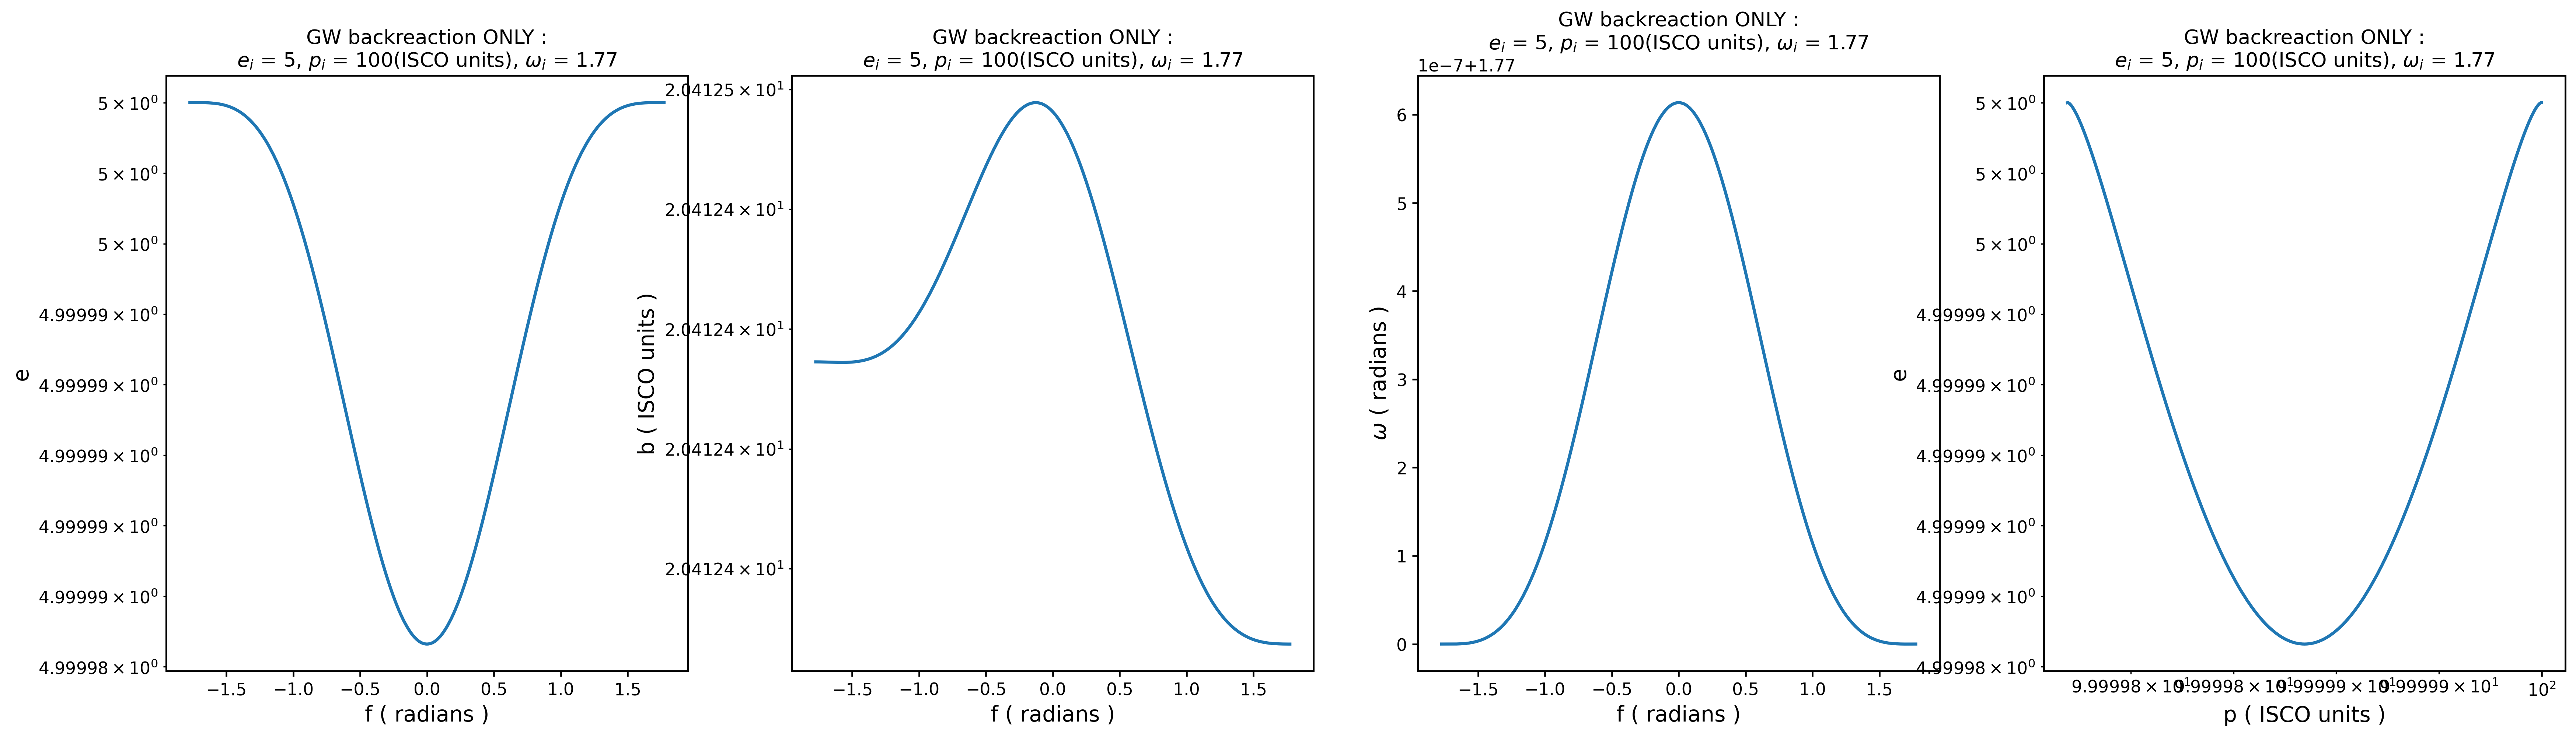

In [12]:
#----FOR GW BACKREACTION ONLY
plt.figure(figsize=(28,7))

plt.subplot(141)
plt.plot( fGW, yGW[0])
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel('e', fontsize =14)
plt.yscale('log')
plt.title('GW backreaction ONLY :'+'\n' +rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.subplot(142)
bGW = yGW[1]/np.sqrt( (yGW[0])**2 - 1 )
plt.plot( fGW, bGW)
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel('b ( ISCO units )', fontsize =14)
plt.yscale('log')
plt.title('GW backreaction ONLY :'+'\n' +rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.subplot(143)
plt.plot( fGW, yGW[2])
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel(r'$\omega$ ( radians )', fontsize =14)
plt.title('GW backreaction ONLY :'+'\n'+ rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

#---'e' Vs 'p'
plt.subplot(144)
plt.plot( yGW[1] , yGW[0])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('p ( ISCO units )', fontsize =14)
plt.ylabel('e', fontsize =14)
plt.title('GW backreaction ONLY :'+'\n'+rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.show()

## Hyperbolic binaries in Static DM environment

#### Dark Matter density parameters

<center>    
$ \rho_{DM} (r) = 
\begin{cases} 
\rho_{sp} \big( \frac{r_{sp}}{r} \big)^{\alpha} &  r_{min} \leq r \leq r_{sp} \\
0 &  r \leq r_{min} \\
\end{cases} $
</center>    

where, for given primary IMBH of mass $10^3 M_{\odot}$, $r_{sp}=0.54pc$, $\rho_{sp} = 226 M_{\odot} / pc^3$ and $r_{min} = r_{ISCO} = 3R_s = 6G m_1/c^2$

In [13]:
# DARK-MATTER MINISPIKE Profile parameters

alpha = 2.35 # DM exponent
rho_sp = (226*M_sun/((pc)**3))*(l0**3 / m0)  # in ISCO units
r_sp = 0.54 * (pc) / l0   # in ISCO units

# FF is needed for DM minispike gravity force ( put FF = 0 to check the Favata result )
def FF(alpha):
    return 4*(np.pi)*(rho_sp)*((r_sp)**alpha )/(3-alpha) 

# Effective mass M_eff needed for DM effect contribution ( DM gravity, DF, Accretion ). 
# For GW backreaction only, we consider total mass M instead
def M_eff(alpha):
    rmin = r_min/l0 # it is basically equal to 1, since everything is in ISCO units
    return (m1 + m2) - (( 4*(np.pi)*(rho_sp)*((r_sp)**alpha)*((rmin)**(3-alpha)) )/(3-alpha))

# Define function for DM minispike density
def rho_dm(y, f, alpha):
    return rho_sp * (r_sp/rel_distance(y, f))**alpha

I_v = 3    # Dynamical friction factor
lamda = 1  # Accretion factor

In [14]:
# Instantaneous osculating equations considering only ( DF + Accretion )
def hyperbolic_osculating_eqn_DF_accretion(f, y, alpha, combination):
    R, S = DF_accretion(y, f, alpha, combination)
    dedf = DeDf_HE(y, f, alpha, combination, R, S)
    dpdf = DpDf_HE(y, f, alpha, combination, R, S)
    domegadf = DomegaDf_HE(y, f, alpha, combination, R, S)
    dtdf = DtDf_HE(y, f, alpha, combination, R, S)
    return [dedf, dpdf, domegadf, dtdf]

# Instantaneous osculating equations considering only DM gravity
def hyperbolic_osculating_eqn_DM_gravity(f, y, alpha, combination):
    R, S = DM_gravity(y, f, alpha)
    dedf = DeDf_HE(y, f, alpha, combination, R, S)
    dpdf = DpDf_HE(y, f, alpha, combination, R, S)
    domegadf = DomegaDf_HE(y, f, alpha, combination, R, S)
    dtdf = DtDf_HE(y, f, alpha, combination, R, S)
    return [dedf, dpdf, domegadf, dtdf]

class hyperbolic_orbit_evolution_with_DM(hyperbolic_orbit_evolution_without_DM):
    # Initial parameters
    def __init__(self, e_i, p_i, omega_i, t_i, alpha):
        super().__init__(e_i, p_i, omega_i, t_i)
        self.alpha = alpha
    # Orbit evolution
    def hyperbolic_orbit_evolution_DM_effect_gw_brxn(self, val, combination):
        # Define the event function
        def stopping_condition(f, y):
            return rel_distance(y, f) - r_min/l0  # Integration stops when distance between binaries reach ISCO

        # Make the event terminal and specify the direction
        stopping_condition.terminal = True    # ensures that the solver stops integration when the event is detected.
        stopping_condition.direction = 0      # allows the detection of zero crossings in any direction (i.e., both increasing and decreasing)
        
        # Coupled osculating equations for NET effect ( Relativistic DF + Accretion + DM gravity + GW brxn )
        def coupled_osculating_eqns(f, y):
            return np.add.reduce([hyperbolic_osculating_eqn_gw_brxn(f, y, val, combination, self.alpha), 
                                  hyperbolic_osculating_eqn_DF_accretion(f, y, self.alpha, combination), 
                                  hyperbolic_osculating_eqn_DM_gravity(f, y, self.alpha, combination)])
        
        # Initial conditions
        initial_conditions = [self.e_i, self.p_i, self.omega_i, self.t_i]

        # Initial value of true anomaly 'f' should be [-np.arccos(-1/e_i)] to correspond binaries starts from very far apart (infinity)
        # but we have added small angle to make sure terms containing (1/(1 + e Cos(f))) doesn't blows up
        f_initial = np.arccos(-1/self.e_i + 1e-4) 

        f_span = (-f_initial, f_initial)   # True anomaly is independent variable here
        
        # Solve the system using solve_ivp
        solution = solve_ivp(coupled_osculating_eqns, f_span, initial_conditions, events=stopping_condition, method='RK45', 
                             atol=1e-12, rtol=1e-8, max_step=0.01) # One can set max_step=100*np.pi

        # print(solution.success)
        # print(solution.status)
        print(solution.message)
        
        return solution.t, solution.y

In [15]:
hyperbolic_sol = hyperbolic_orbit_evolution_with_DM(e_i, p_i, omega_i, t_i, alpha)

# For NET effect set combination = 3
f_NET, y_NET = hyperbolic_sol.hyperbolic_orbit_evolution_DM_effect_gw_brxn(val=0, combination=3)

The solver successfully reached the end of the integration interval.


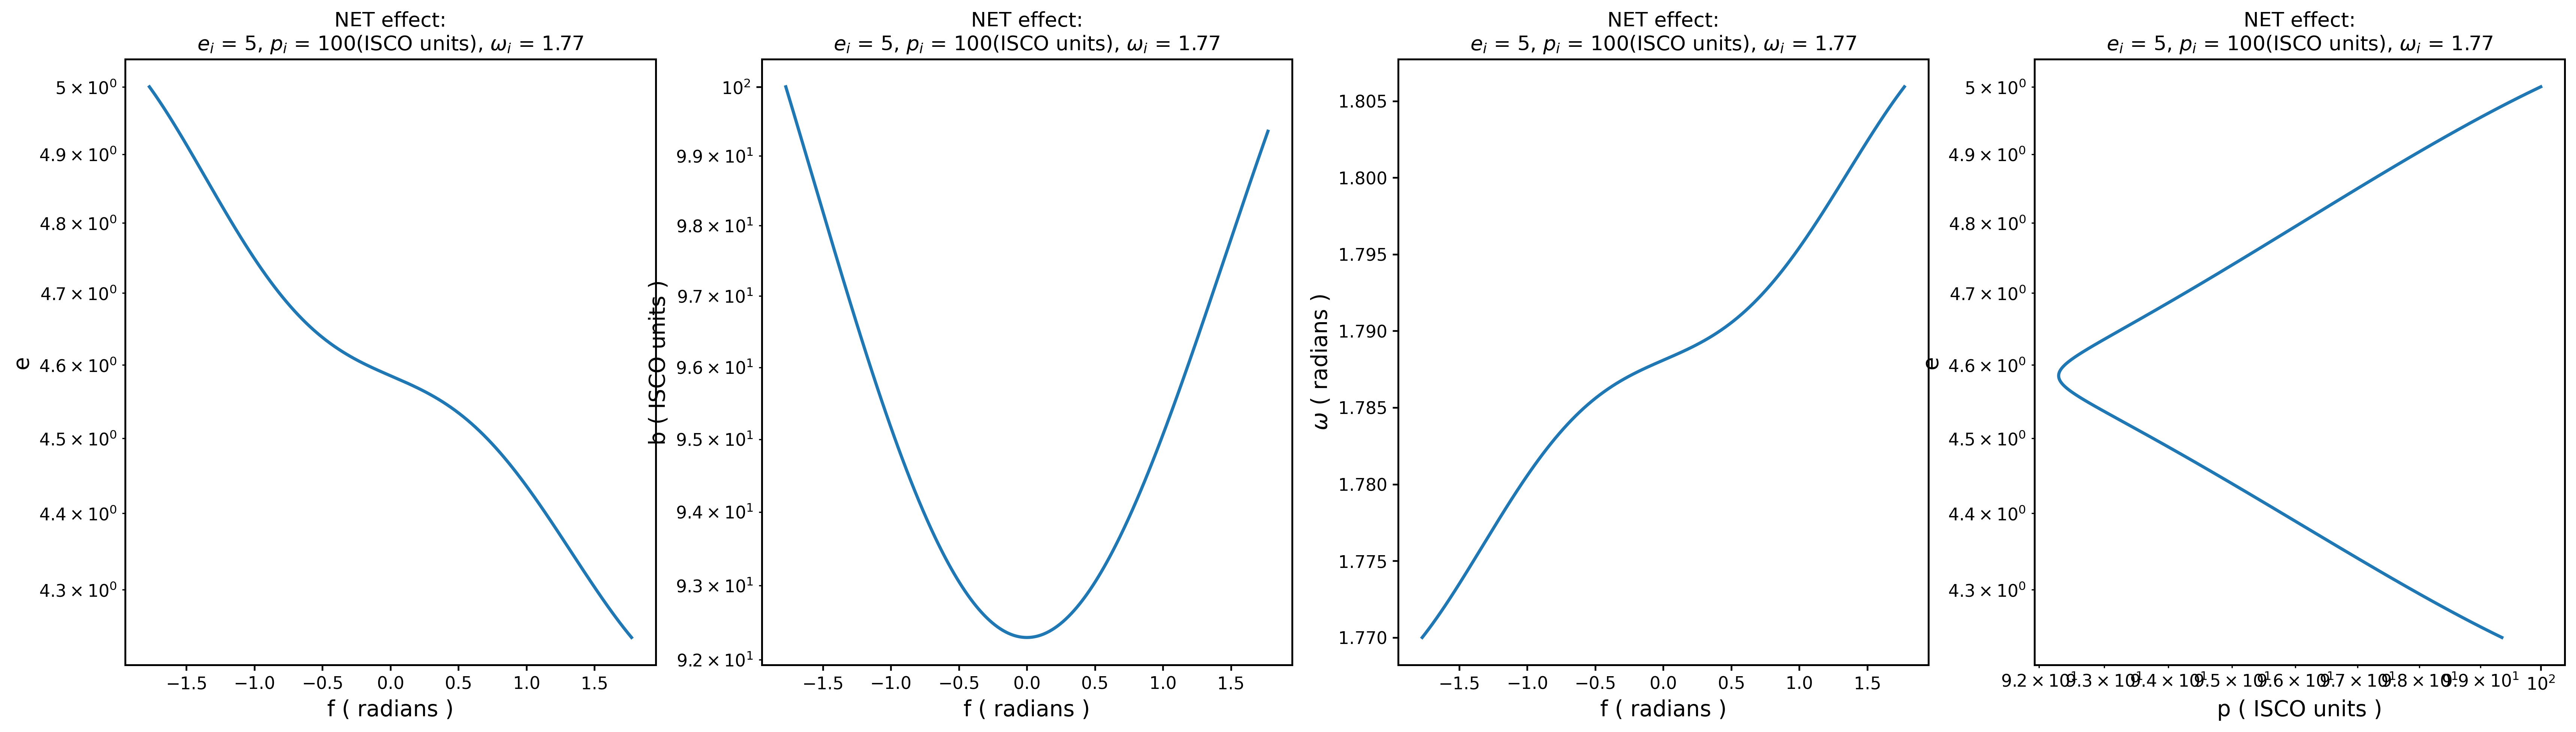

In [16]:
#----For NET effect
plt.figure(figsize=(28,7))

plt.subplot(141)
plt.plot( f_NET, y_NET[0])
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel('e', fontsize =14)
plt.yscale('log')
plt.title('NET effect:'+'\n'+rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.subplot(142)
b_NET = y_NET[1]/np.sqrt( (y_NET[0])**2 - 1 )
plt.plot( f_NET, y_NET[1])
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel('b ( ISCO units )', fontsize =14)
plt.yscale('log')
plt.title('NET effect:'+'\n'+rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.subplot(143)
plt.plot( f_NET, y_NET[2])
plt.xlabel('f ( radians )', fontsize =14)
plt.ylabel(r'$\omega$ ( radians )', fontsize =14)
plt.title('NET effect:'+'\n'+rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

#----'e' Vs 'p'
plt.subplot(144)
plt.plot( y_NET[1] , y_NET[0])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('p ( ISCO units )', fontsize =14)
plt.ylabel('e', fontsize =14)
plt.title('NET effect:'+'\n'+rf'$e_i$ = {e_i}, $p_i$ = {p_i}(ISCO units), $\omega_i$ = {omega_i}')

plt.show()

## Hyperbolic: Nonlinear GW memory

#### Perturbed Kepler equation of motion 

The perurbed Newtonian binary we are setting up is (or say perturbed Kepler e.o.m ) -

$ \ddot{r} = r \dot{\phi}^2 - G \frac{m}{r^2} - G \frac{F}{r^{\alpha -1}} - G^2 \frac{4\pi m_2 \rho_{DM} (I_v \xi (v) + \lambda) \dot{r}}{v^3} - \frac{G M}{r^2} \big[ ( \frac{A_{1PN}}{c^2} + \frac{A_{2PN}}{c^4} + \frac{A_{2.5PN}}{c^5}) + \dot{r} ( \frac{B_{1PN}}{c^2} + \frac{B_{2PN}}{c^4} + \frac{B_{2.5PN}}{c^5} ) \big]$

$ \ddot{\phi} = - \frac{2 \dot{r} \dot{\phi}}{r} - G^2 \frac{4\pi m_2 \rho_{DM} (I_v \xi (v) + \lambda) \dot{\phi}}{v^3} -\frac{G M}{r^2} \big[ \dot{\phi} ( \frac{B_{1PN}}{c^2} + \frac{B_{2PN}}{c^4} + \frac{B_{2.5PN}}{c^5} ) \big] $

where,

$ A_{1PN} = -\frac{ 3 {\dot{r}}^2 \eta}{2} + v^2 + 3 \eta v^2 - \frac{G M}{r} (4 + 2 \eta)$

$ A_{2PN} = \frac{15 {\dot{r}}^4 \eta }{8} - \frac{45 {\dot{r}}^4 {\eta}^2 }{8} - \frac{9 {\dot{r}}^2 \eta v^2}{2} + 6{\dot{r}}^2 {\eta}^2 v^2 + 3\eta v^4 - 4 {\eta}^2 v^4 + \frac{G M}{r} \big[ - 2 {\dot{r}}^2 - 25 {\dot{r}}^2 {\eta} -2{\dot{r}}^2 {\eta}^2- \frac{13 \eta v^2}{2} + 2 {\eta}^2 v^2 \big] + \frac{G^2 M^2}{r^2} \big[ 9 + \frac{87 \eta}{4} \big]$

$ A_{2.5PN} = \frac{8 G M \eta}{5 r} \dot{r}  \big[ -\frac{17}{3} \frac{G M}{r} - 3 v^2 \big] $

$ B_{1PN} = - 4 \dot{r} + 2 \dot{r} \eta $

$ B_{2PN} = \frac{9 {\dot{r}}^3 \eta}{2} + 3 {\dot{r}}^3 {\eta}^2 - \frac{15 \dot{r} \eta v^2}{2} - 2 \dot{r} {\eta}^2 v^2 + \frac{G M}{r} \big[ 2 \dot{r} + \frac{41 \dot{r} \eta }{2} + 4 \dot{r} {\eta}^2 \big] $

$ B_{2.5PN} = \frac{8 G M \eta }{5 r } \big[ 3 \frac{G M}{r } + v^2 \big]$

And, 

$ \dot{r} = \sqrt{\frac{Gm}{p}} e \sin{f} $

$ \dot{f} = \dot{\phi} = \sqrt{\frac{Gm}{p^3}}(1 + e \cos{f} )^2 $

$ v = \sqrt{ {\dot{r}}^2 + r^2 {\dot{\phi}}^2}$

Relativistic factor DF : $ \xi (v) = \gamma^2 (1+ v^2)^2 $

$ \gamma = \sqrt{1-v^2}$

And,

$ F = \frac{4\pi \rho_{sp} {r_{sp}}^{\alpha} }{(3-\alpha)} $

$  m = M_{eff} = M - \frac{4\pi \rho_{sp} {r_{sp}}^{\alpha} {r_{min}}^{3-\alpha}}{(3-\alpha)}$

$ M = m_1 + m_2 $ 

Set everything in Geometrized units $ \boxed{ G = c = 1 }$

In [17]:
# SYMBOLIC CALCULATIONS

# Declare constants
m_, eta_, F_, alpha_, m2_, rho_sp_, r_sp_, Iv_, lamda_ = sp.symbols('m eta F alpha m2 rho_sp r_sp Iv lamda')

# Declare independent variable time as symbol
t_ = sp.symbols('t')

# Declare time-dependent functions
r_ = sp.Function('r')(t_)
phi_ = sp.Function('phi')(t_)
drdt_ = sp.Function('drdt')(t_) 
dphidt_ = sp.Function('dphidt')(t_)

# Declare time derivatives of 'r' and 'phi' as symbols 
r_dot_, r_dotdot_, r_dotdotdot_, phi_dot_, phi_dotdot_, phi_dotdotdot_ = sp.symbols('r_dot r_dotdot r_dotdotdot phi_dot phi_dotdot phi_dotdotdot')

# Define expressions for velocity 'v'
v_ = sp.sqrt( drdt_**2 + (r_**2) * (dphidt_**2) )

# Define expression for DM minispike density
rho_dm_ = rho_sp_ * ((r_sp_/r_)**alpha_)

# Relativistic DF factor
xi_ = ( 1 - v_**2 ) * ( 1 + v_**2 )**2

# Define expression of PN correction from GW radiation reaction
A1PN_ = ( -3*(drdt_**2)*eta_/2 + v_**2 + 3*eta_*(v_**2) - (m_/r_)*( 4 + 2*eta_ ) )
A2PN_ = ( 15*(drdt_**4)*eta_/8 - 45*(drdt_**4)*(eta_**2)/8  - 9*(drdt_**2)*eta_*(v_**2)/2 + 6*(drdt_**2)*(eta_**2)*(v_**2) + 3*eta_*(v_**4)
         - 4*(eta_**2)*(v_**4) + (m_/r_)*( -2*(drdt_**2) - 25*(drdt_**2)*eta_ - 2*(drdt_**2)*(eta_**2) -13*eta_*(v_**2)/2 + 
                                              2*(eta_**2)*(v_**2) )  )
A2pt5PN_ = (( 8*m_*eta_*drdt_/(5*r_) )*( - 17*m_/(3*r_) - 3*(v_**2) ))

B1PN_ = ( -4*drdt_ + 2*drdt_*eta_ )
B2PN_ = ( 9*(drdt_**3)*eta_/2 + 3*(drdt_**3)*(eta_**2) - 15*drdt_*eta_*(v_**2)/2 - 2*drdt_*(eta_**2)*(v_**2)      
         + (m_/r_)*(  2*drdt_ + 41*drdt_*eta_/2 + 4*drdt_*(eta_**2) ) )
B2pt5PN_ = ( 8*m_*eta_/(5*r_) )*(  3*(m_/r_) + (v_**2)  )

# Eccentric : Perturbed Newtonian binary e.o.m
d2rdt2_ = ( (r_*(dphidt_**2)) - (m_/(r_**2)) - (F_/(r_**(alpha_-1))) - (4*sp.pi*m2_*rho_dm_*(Iv_*xi_+lamda_)*drdt_/(v_**3)) \
            - (m_/(r_**2))*( (A1PN_ + A2PN_ + A2pt5PN_) + drdt_*(B1PN_ + B2PN_ + B2pt5PN_) ) )
d2phidt2_ = ( -((2*drdt_*dphidt_)/r_) - (4*sp.pi*m2_*rho_dm_*(Iv_*xi_+lamda_)*dphidt_/(v_**3)) \
                - (m_/(r_**2))*dphidt_*(B1PN_ + B2PN_ + B2pt5PN_)  ) 

# print(f'd2rdt2 = {d2rdt2_}' + '\n') 
# print(f'd2phidt2 = {d2phidt2_}' + '\n')

# 3rd-time derivative of 'r' and 'phi'
d3rdt3_ = sp.simplify(sp.diff(d2rdt2_, t_))
d3phidt3_ = sp.simplify(sp.diff(d2phidt2_, t_))

# Substitute 'r' and 'phi' time derivatives as symbols
d3rdt3 = d3rdt3_.subs({
    sp.Derivative(r_, t_): r_dot_,
    drdt_ : r_dot_,
    sp.Derivative(drdt_, t_): r_dotdot_,
    sp.Derivative(phi_, t_): phi_dot_,
    dphidt_ : phi_dot_,
    sp.Derivative(dphidt_, t_): phi_dotdot_})

d3phidt3 = d3phidt3_.subs({
    sp.Derivative(r_, t_): r_dot_,
    drdt_ : r_dot_,
    sp.Derivative(drdt_, t_): r_dotdot_,
    sp.Derivative(phi_, t_): phi_dot_,
    dphidt_ : phi_dot_,
    sp.Derivative(dphidt_, t_): phi_dotdot_})

# Print to check derivatives were done correctly
# print(f'd3rdt3 = {sp.simplify(d3rdt3)}' + '\n') 
# print(f'd3phidt3 = {sp.simplify(d3phidt3)}' + '\n')
 
# Create numerical function of 3rd-time derivative of 'r' and 'phi'
r_dotdotdot_func = sp.lambdify((r_, r_dot_, r_dotdot_, phi_dot_, phi_dotdot_,
                                m_, eta_, F_, alpha_, m2_, rho_sp_, r_sp_, Iv_, lamda_), sp.simplify(d3rdt3), modules='numpy')
phi_dotdotdot_func = sp.lambdify((r_, r_dot_, r_dotdot_, phi_dot_, phi_dotdot_,
                                  m_, eta_, F_, alpha_, m2_, rho_sp_, r_sp_, Iv_, lamda_), sp.simplify(d3phidt3), modules='numpy')

i = 1j # complex number

# Define the expression for Mass-quadrupole moments
I20_ = -4 * sp.sqrt(sp.pi / 15) * eta_ * m_ * r_**2
I22P_ = 2 * sp.sqrt(2*sp.pi/5) * eta_ * m_ * r_**2 * sp.exp(-2*i*phi_)
I22M_ = 2 * sp.sqrt(2*sp.pi/5) * eta_ * m_ * r_**2 * sp.exp( 2*i*phi_)

# 3rd-time derivative of Mass-qudrupole moments
I20ddd_  = sp.simplify(sp.diff(I20_, t_, 3))
I22Pddd_ = sp.simplify(sp.diff(I22P_, t_, 3))
I22Mddd_ = sp.simplify(sp.diff(I22M_, t_, 3))

# Substitute 'r' and 'phi' time derivatives as symbols
I20ddd = I20ddd_.subs({
    sp.Derivative(r_, t_): r_dot_,
    sp.Derivative(r_, t_, 2): r_dotdot_,
    sp.Derivative(r_, t_, 3): r_dotdotdot_,
    sp.Derivative(phi_, t_): phi_dot_,
    sp.Derivative(phi_, t_, 2): phi_dotdot_,
    sp.Derivative(phi_, t_, 3): phi_dotdotdot_})

I22Pddd = I22Pddd_.subs({
    sp.Derivative(r_, t_): r_dot_,
    sp.Derivative(r_, t_, 2): r_dotdot_,
    sp.Derivative(r_, t_, 3): r_dotdotdot_,
    sp.Derivative(phi_, t_): phi_dot_,
    sp.Derivative(phi_, t_, 2): phi_dotdot_,
    sp.Derivative(phi_, t_, 3): phi_dotdotdot_})

I22Mddd = I22Mddd_.subs({
    sp.Derivative(r_, t_): r_dot_,
    sp.Derivative(r_, t_, 2): r_dotdot_,
    sp.Derivative(r_, t_, 3): r_dotdotdot_,
    sp.Derivative(phi_, t_): phi_dot_,
    sp.Derivative(phi_, t_, 2): phi_dotdot_,
    sp.Derivative(phi_, t_, 3): phi_dotdotdot_})

# Print to check derivatives were done correctly
# print(f'I20ddd = {sp.simplify(I20ddd)}' + '\n') 
# print(f'I22Pddd = {sp.simplify(I22Pddd)}' + '\n') 
# print(f'I22Mddd = {sp.simplify(I22Mddd)}') 

# Create numerical function of 3rd-time derivative of quadrupole moments
I20ddd_func  = sp.lambdify((r_, phi_, r_dot_, r_dotdot_, r_dotdotdot_, phi_dot_, phi_dotdot_, phi_dotdotdot_, m_, eta_), 
                           sp.simplify(I20ddd), modules='numpy')
I22Pddd_func = sp.lambdify((r_, phi_, r_dot_, r_dotdot_, r_dotdotdot_, phi_dot_, phi_dotdot_, phi_dotdotdot_, m_, eta_), 
                           sp.simplify(I22Pddd), modules='numpy')
I22Mddd_func = sp.lambdify((r_, phi_, r_dot_, r_dotdot_, r_dotdotdot_, phi_dot_, phi_dotdot_, phi_dotdotdot_, m_, eta_), 
                           sp.simplify(I22Mddd), modules='numpy')

In [18]:
# Define PN correction terms from GW radiation reaction to relative acceleration
def PN_terms(y, f, alpha, combination):
    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    phidot = phi_dot(y, f, alpha, combination)
    velocity = v(y, f, alpha, combination)
    m = M
    # PN terms
    A1PN = ( -3*(rdot**2)*eta/2 + velocity**2 + 3*eta*(velocity**2) - (m/r)*( 4 + 2*eta ) )
    A2PN = ( 15*(rdot**4)*eta/8 - 45*(rdot**4)*(eta**2)/8  - 9*(rdot**2)*eta*(velocity**2)/2 + 6*(rdot**2)*(eta**2)*(velocity**2) 
             + 3*eta*(velocity**4) - 4*(eta**2)*(velocity**4) + (m/r)*( -2*(rdot**2) - 25*(rdot**2)*eta 
             - 2*(rdot**2)*(eta**2) -13*eta*(velocity**2)/2 + 2*(eta**2)*(velocity**2) ) )
    A2pt5PN = (( 8*m*eta*rdot/(5*r) )*( - 17*m/(3*r) - 3*(velocity**2) ))
    
    B1PN = ( -4*rdot + 2*rdot*eta )
    B2PN = ( 9*(rdot**3)*eta/2 + 3*(rdot**3)*(eta**2) - 15*rdot*eta*(velocity**2)/2 - 2*rdot*(eta**2)*(velocity**2)      
             + (m/r)*(  2*rdot + 41*rdot*eta/2 + 4*rdot*(eta**2) ) )
    B2pt5PN = ( 8*m*eta/(5*r) )*(  3*(m/r) + (velocity**2)  )
    return A1PN, A2PN, A2pt5PN, B1PN, B2PN, B2pt5PN

# Eccentric : Perturbed Newtonian binary 
def r_dotdot(y, f, alpha, combination, val): # Radial e.o.m
    if combination==0: # Switch OFF all DM environment effects i.e we observe just GW backrxn effect
        F = 0
        rhodm = 0
        m = M
    if combination==1 or combination==11: # Switch OFF DM minispike gravity only i.e we observe (DF + GW backrxn)
        F = 0
        rhodm = rho_dm(y, f, alpha)
        m = M
    else: # Switch ON all DM environment effects + GW backrxn
        F = FF(alpha)
        rhodm = rho_dm(y, f, alpha)
        m = M_eff(alpha)
        
    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    phidot = phi_dot(y, f, alpha, combination)
    velocity = v(y, f, alpha, combination)
    # GR PN correction terms upto 2.5 PN
    A1PN, A2PN, A2pt5PN, B1PN, B2PN, B2pt5PN = PN_terms(y, f, alpha, combination)

    if val==2.5: # Newtonian binary e.o.m (NOTE: When val=2.5 then combination should also = 0 to derive FAVATA result)
        return (r * phidot**2 - (m)/(r**2) - (m/(r**2))*( A2pt5PN + rdot*B2pt5PN ) )
    else:  # Perturbed Newtonian binary e.o.m
        return (r * phidot**2 - (m)/(r**2) - (F)/(r**(alpha-1)) - 4 * np.pi * m2 * rhodm * (I_v*xi(velocity)+lamda) * rdot/velocity**3 
                - (m/(r**2))*( (A1PN + A2PN + A2pt5PN) + rdot*(B1PN + B2PN + B2pt5PN) ) )
    
def phi_dotdot(y, f, alpha, combination, val): # Azimuthal angle e.o.m
    if combination==0: # Switch OFF all DM environment effects i.e we observe just GW backrxn effect
        F = 0
        rhodm = 0
        m = M
    if combination==1 or combination==11: # Switch OFF DM minispike gravity only i.e we observe (DF + GW backrxn)
        F = 0
        rhodm = rho_dm(y, f, alpha)
        m = M
    else: # Switch ON all DM environment effects + GW backrxn
        F = FF(alpha)
        rhodm = rho_dm(y, f, alpha)
        m = M_eff(alpha)
        
    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    phidot = phi_dot(y, f, alpha, combination)
    velocity = v(y, f, alpha, combination)
    # GR PN correction terms upto 2.5 PN
    A1PN, A2PN, A2pt5PN, B1PN, B2PN, B2pt5PN = PN_terms(y, f, alpha, combination)

    if val==2.5: # Newtonian binary e.o.m (NOTE: When val=2.5 then combination should also = 0 to derive FAVATA result)
        return -2*rdot*phidot/r - (m/(r**2))*( phidot* B2pt5PN )
    else:  # Perturbed Newtonian binary e.o.m
        return (-2*rdot*phidot/r - 4 * np.pi * m2 * rhodm * (I_v*xi(velocity)+lamda) * phidot/velocity**3 
                - (m/(r**2))*( phidot*(B1PN + B2PN + B2pt5PN) ) )

def dh20dt_mem(y, f, R, alpha, combination, val):
    if combination==0: # Switch OFF all DM environment effects i.e we observe just GW backrxn effect
        F = 0
        rhosp = 0
        m = M
    if combination==1 or combination==11: # Switch OFF DM minispike gravity only i.e we observe (Relativistic DF + GW backrxn)
        F = 0
        rhosp = rho_sp
        m = M
    else: # Switch ON all DM environment effects + GW backrxn
        F = FF(alpha)
        rhosp = rho_sp
        m = M_eff(alpha)
        
    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    rdotdot = r_dotdot(y, f, alpha, combination, val)
    phidot = phi_dot(y, f, alpha, combination)
    phidotdot = phi_dotdot(y, f, alpha, combination, val)

    rdotdotdot = r_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)
    phidotdotdot = phi_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)

    h20dotN =  I20ddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta )/(R * np.sqrt(2))
    h22PdotN = I22Pddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))
    h22MdotN = I22Mddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))
    h22dotN = (np.abs( h22PdotN * h22MdotN ))**(1/2)

    return (R/42)*(np.sqrt(15/(2*np.pi)))*( 2 * (h22dotN**2) - (h20dotN**2) )
    

def dh40dt_mem(y, f, R, alpha, combination, val):
    if combination==0: # Switch OFF all DM environment effects i.e we observe just GW backrxn effect
        F = 0
        rhosp = 0
        m = M
    if combination==1 or combination==11: # Switch OFF DM minispike gravity only i.e we observe (DF + GW backrxn)
        F = 0
        rhosp = rho_sp
        m = M
    else: # Switch ON all DM environment effects + GW backrxn
        F = FF(alpha)
        rhosp = rho_sp
        m = M_eff(alpha)

    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    rdotdot = r_dotdot(y, f, alpha, combination, val)
    phidot = phi_dot(y, f, alpha, combination)
    phidotdot = phi_dotdot(y, f, alpha, combination, val)
    
    rdotdotdot = r_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)
    phidotdotdot = phi_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)

    h20dotN =  I20ddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta )/(R * np.sqrt(2))
    h22PdotN = I22Pddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))
    h22MdotN = I22Mddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))
    h22dotN = (np.abs( h22PdotN * h22MdotN ))**(1/2)

    return (R/1260)*(np.sqrt(5/(2*np.pi)))*( (h22dotN**2) + 3 * (h20dotN**2) )

def dh22dt_mem(y, f, R, alpha, combination, val):
    if combination==0: # Switch OFF all DM environment effects i.e we observe just GW backrxn effect
        F = 0
        rhosp = 0
        m = M
    if combination==1 or combination==11: # Switch OFF DM minispike gravity only i.e we observe (DF + GW backrxn)
        F = 0
        rhosp = rho_sp
        m = M
    else: # Switch ON all DM environment effects + GW backrxn
        F = FF(alpha)
        rhosp = rho_sp
        m = M_eff(alpha)

    r = rel_distance(y, f)
    rdot = r_dot(y, f, alpha, combination)
    rdotdot = r_dotdot(y, f, alpha, combination, val)
    phidot = phi_dot(y, f, alpha, combination)
    phidotdot = phi_dotdot(y, f, alpha, combination, val)
    
    rdotdotdot = r_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)
    phidotdotdot = phi_dotdotdot_func(r, rdot, rdotdot, phidot, phidotdot, m, eta, F, alpha, m2, rhosp, r_sp, I_v, lamda)

    h20dotN =  I20ddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta )/(R * np.sqrt(2))
    h22PdotN = I22Pddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))
    h22MdotN = I22Mddd_func(r, f, rdot, rdotdot, rdotdotdot, phidot, phidotdot, phidotdotdot, M, eta)/(R * np.sqrt(2))

    return (R/21)*(np.sqrt(15/(2*np.pi)))*( h22PdotN * h20dotN ), (R/21)*(np.sqrt(15/(2*np.pi)))*( h22MdotN * h20dotN )

# Calculating hlm (l, m = 20, 22+, 22-, 40) mode of Nonlinear memory
class hyperbolic_calculate_nonlinear_memory(hyperbolic_orbit_evolution_with_DM):
    # Initial parameters
    def __init__(self, e_i, p_i, omega_i, t_i, alpha, R):
        super().__init__(e_i, p_i, omega_i, t_i, alpha)
        self.R = R
        
    def cal_hl0(self, val, combination): 
        sol_without_DM = hyperbolic_orbit_evolution_without_DM(self.e_i, self.p_i, self.omega_i, self.t_i)
        sol_with_DM = hyperbolic_orbit_evolution_with_DM(self.e_i, self.p_i, self.omega_i, self.t_i, self.alpha)
        
        if combination==0: # GW backrxn only ( FAVATA result )
            f, y = sol_without_DM.hyperbolic_orbit_evolution_gw_brxn(val)
        else: # NET : DF + Accretion + DM gravity + GW backrxn
            f, y = sol_with_DM.hyperbolic_orbit_evolution_DM_effect_gw_brxn(val, 3)

        e, p, omega, t = y
        num = len(e)

        h20dot_mem = dh20dt_mem(y, f, self.R, self.alpha, combination, val)
        h40dot_mem = dh40dt_mem(y, f, self.R, self.alpha, combination, val)
        h22Pdot_mem, h22Mdot_mem = dh22dt_mem(y, f, self.R, self.alpha, combination, val)

        dh20df_mem = []
        dh40df_mem = []
        dh22Pdf_mem = []
        dh22Mdf_mem = []

        # Calculating h20_mem, h22P_mem, h22M_mem and h40_mem as function of true anomaly using Euler's method
        h20_mem = np.zeros((np.shape(e))) 
        h40_mem = np.zeros((np.shape(e)))
        h22P_mem = np.zeros(shape=np.shape(e), dtype=complex) 
        h22M_mem = np.zeros(shape=np.shape(e), dtype=complex) 

        for i in range(num):
            if combination==0: # GW backrxn only ( FAVATA result )
                dedf, dpdf, domegadf, dtdf = hyperbolic_osculating_eqn_gw_brxn(f[i], y[:,i], val, combination, self.alpha)
                dh20df_mem.append( h20dot_mem[i] * dtdf ) 
                dh40df_mem.append( h40dot_mem[i] * dtdf )
                dh22Pdf_mem.append( h22Pdot_mem[i] * dtdf ) 
                dh22Mdf_mem.append( h22Mdot_mem[i] * dtdf ) 
            else: # NET : Relativistic DF + Accretion + DM gravity + GW backrxn
                dedf, dpdf, domegadf, dtdf = np.add.reduce([hyperbolic_osculating_eqn_gw_brxn(f[i],y[:,i],val,combination,self.alpha),
                                               hyperbolic_osculating_eqn_DF_accretion(f[i], y[:,i], self.alpha, combination),
                                               hyperbolic_osculating_eqn_DM_gravity(f[i], y[:,i], self.alpha, combination)])
                dh20df_mem.append( h20dot_mem[i] * dtdf ) 
                dh40df_mem.append( h40dot_mem[i] * dtdf ) 
                dh22Pdf_mem.append( h22Pdot_mem[i] * dtdf ) 
                dh22Mdf_mem.append( h22Mdot_mem[i] * dtdf ) 

            if i<(num-1):
                # Euler method
                h20_mem[i+1] = h20_mem[i] + dh20df_mem[i] * ( f[i+1] - f[i] ) 
                h40_mem[i+1] = h40_mem[i] + dh40df_mem[i] * ( f[i+1] - f[i] )
                h22P_mem[i+1] = h22P_mem[i] + dh22Pdf_mem[i] * ( f[i+1] - f[i] ) 
                h22M_mem[i+1] = h22M_mem[i] + dh22Mdf_mem[i] * ( f[i+1] - f[i] ) 

        return f, y, h20_mem, h40_mem, h22P_mem, h22M_mem

In [19]:
# Calculating Nonlinear GW memory for given initial orbital parameters
hyperbolic_nonlinear_memory = hyperbolic_calculate_nonlinear_memory(e_i, p_i, omega_i, t_i, alpha, R)

# Only GW backreaction ( FAVATA result )
fgw, ygw, h20_mem_gw, h40_mem_gw, h22P_mem_gw, h22M_mem_gw = hyperbolic_nonlinear_memory.cal_hl0(val=2.5, combination=0)

print('h20_mem_gw = ',h20_mem_gw[-1])
print('h22P_mem_gw = ',h22P_mem_gw[-1])
print('h22M_mem_gw = ',h22M_mem_gw[-1])
print('h40_mem_gw = ',h40_mem_gw[-1])

# NET : DM gravity + Relativistic DF + Accretion + GW brxn
f_net, y_net, h20_mem_NET, h40_mem_NET, h22P_mem_NET, h22M_mem_NET = hyperbolic_nonlinear_memory.cal_hl0(val=0, combination=3)

print('h20_mem_NET = ',h20_mem_NET[-1])
print('h22P_mem_NET = ',h22P_mem_NET[-1])
print('h22M_mem_NET = ',h22M_mem_NET[-1])
print('h40_mem_NET = ',h40_mem_NET[-1])

The solver successfully reached the end of the integration interval.
h20_mem_gw =  9.306863128123444e-28
h22P_mem_gw =  (5.577546169575129e-29+1.9189758933041974e-34j)
h22M_mem_gw =  (5.577546169575129e-29-1.9189758933041974e-34j)
h40_mem_gw =  9.292207299126259e-30
The solver successfully reached the end of the integration interval.
h20_mem_NET =  2.5509525371555737e-27
h22P_mem_NET =  (7.382089965259191e-29+1.0539914563735466e-31j)
h22M_mem_NET =  (7.382089965259191e-29-1.0539914563735466e-31j)
h40_mem_NET =  2.486491841765057e-29


In [20]:
# FOR - Only GW backreaction ( FAVATA result )
np.save("hyp_fgw.npy", fgw)   # saves array to file
np.save("hyp_ygw.npy", ygw)
np.save("hyp_h20_mem_gw.npy", h20_mem_gw)
np.save("hyp_h40_mem_gw.npy", h40_mem_gw)

# FOR - NET : DM gravity + DF + Accretion + GW brxn
np.save("hyp_spike_f_net.npy", f_net)   # saves array to file
np.save("hyp_spike_y_net.npy", y_net) 
np.save("hyp_spike_h20_mem_NET.npy", h20_mem_NET)
np.save("hyp_spike_h40_mem_NET.npy", h40_mem_NET)
%store alpha

Stored 'alpha' (float)


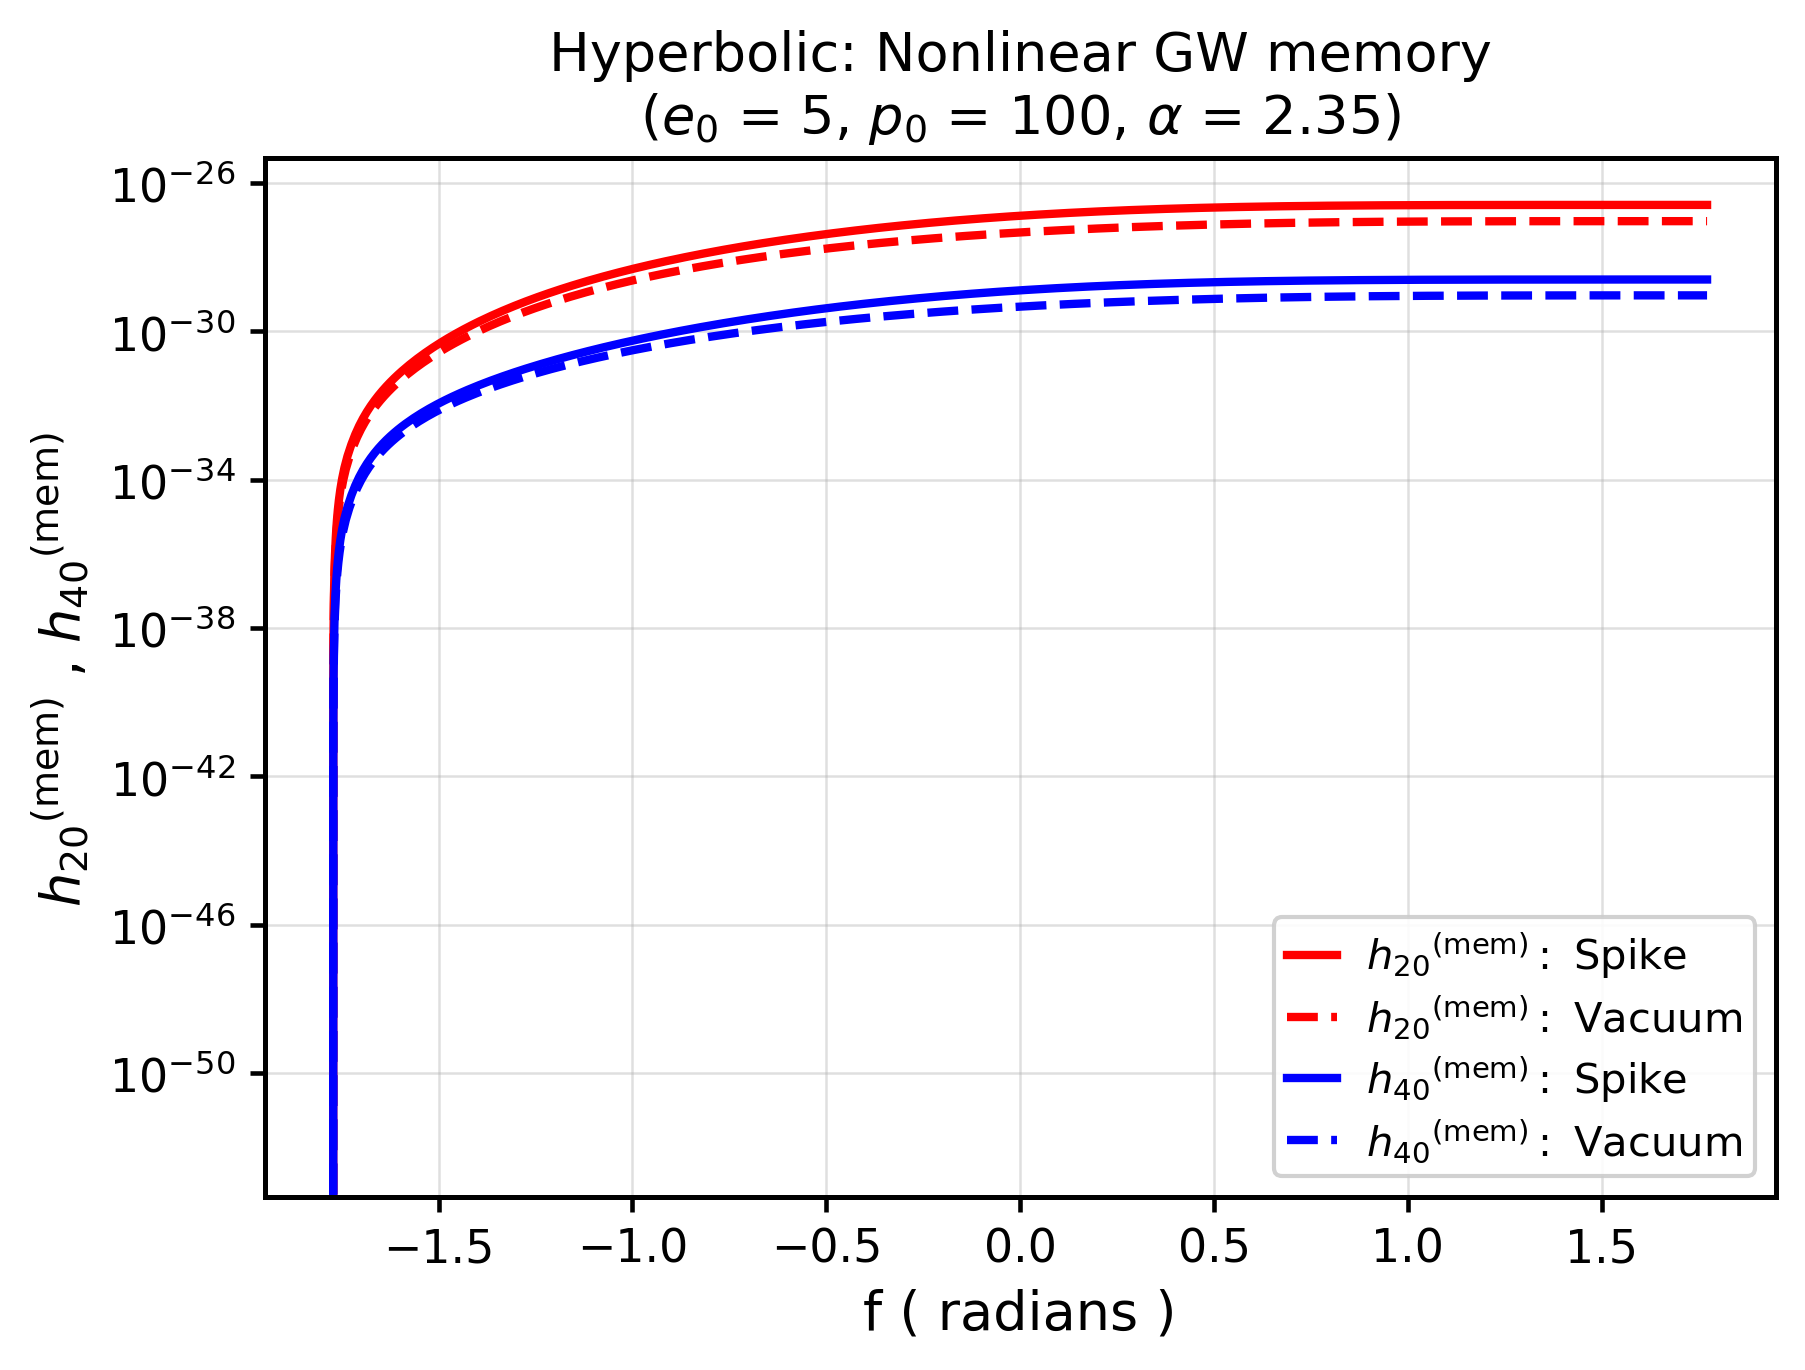

In [21]:
# Plotting
plt.figure()
plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_i}, $p_0$ = {p_i}, '+r'${{\alpha}}$' +f' = {alpha})')

plt.plot( f_net, h20_mem_NET, label = r' ${h_{20}}^{\text{(mem)}}:$' +' Spike', linestyle='-', color='red' )
plt.plot( fgw, h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + ' Vacuum', linestyle='--', color='red')

plt.plot( f_net, h40_mem_NET, label = r' ${h_{40}}^{\text{(mem)}}:$' + ' Spike', linestyle='-', color='blue' )
plt.plot( fgw, h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}:$' + ' Vacuum', linestyle='--', color='blue')

plt.xlabel('f ( radians )')
plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Save as PDF
# plt.savefig("hyperbolic_spike_plot_1.pdf", format="pdf", bbox_inches="tight")

plt.show()

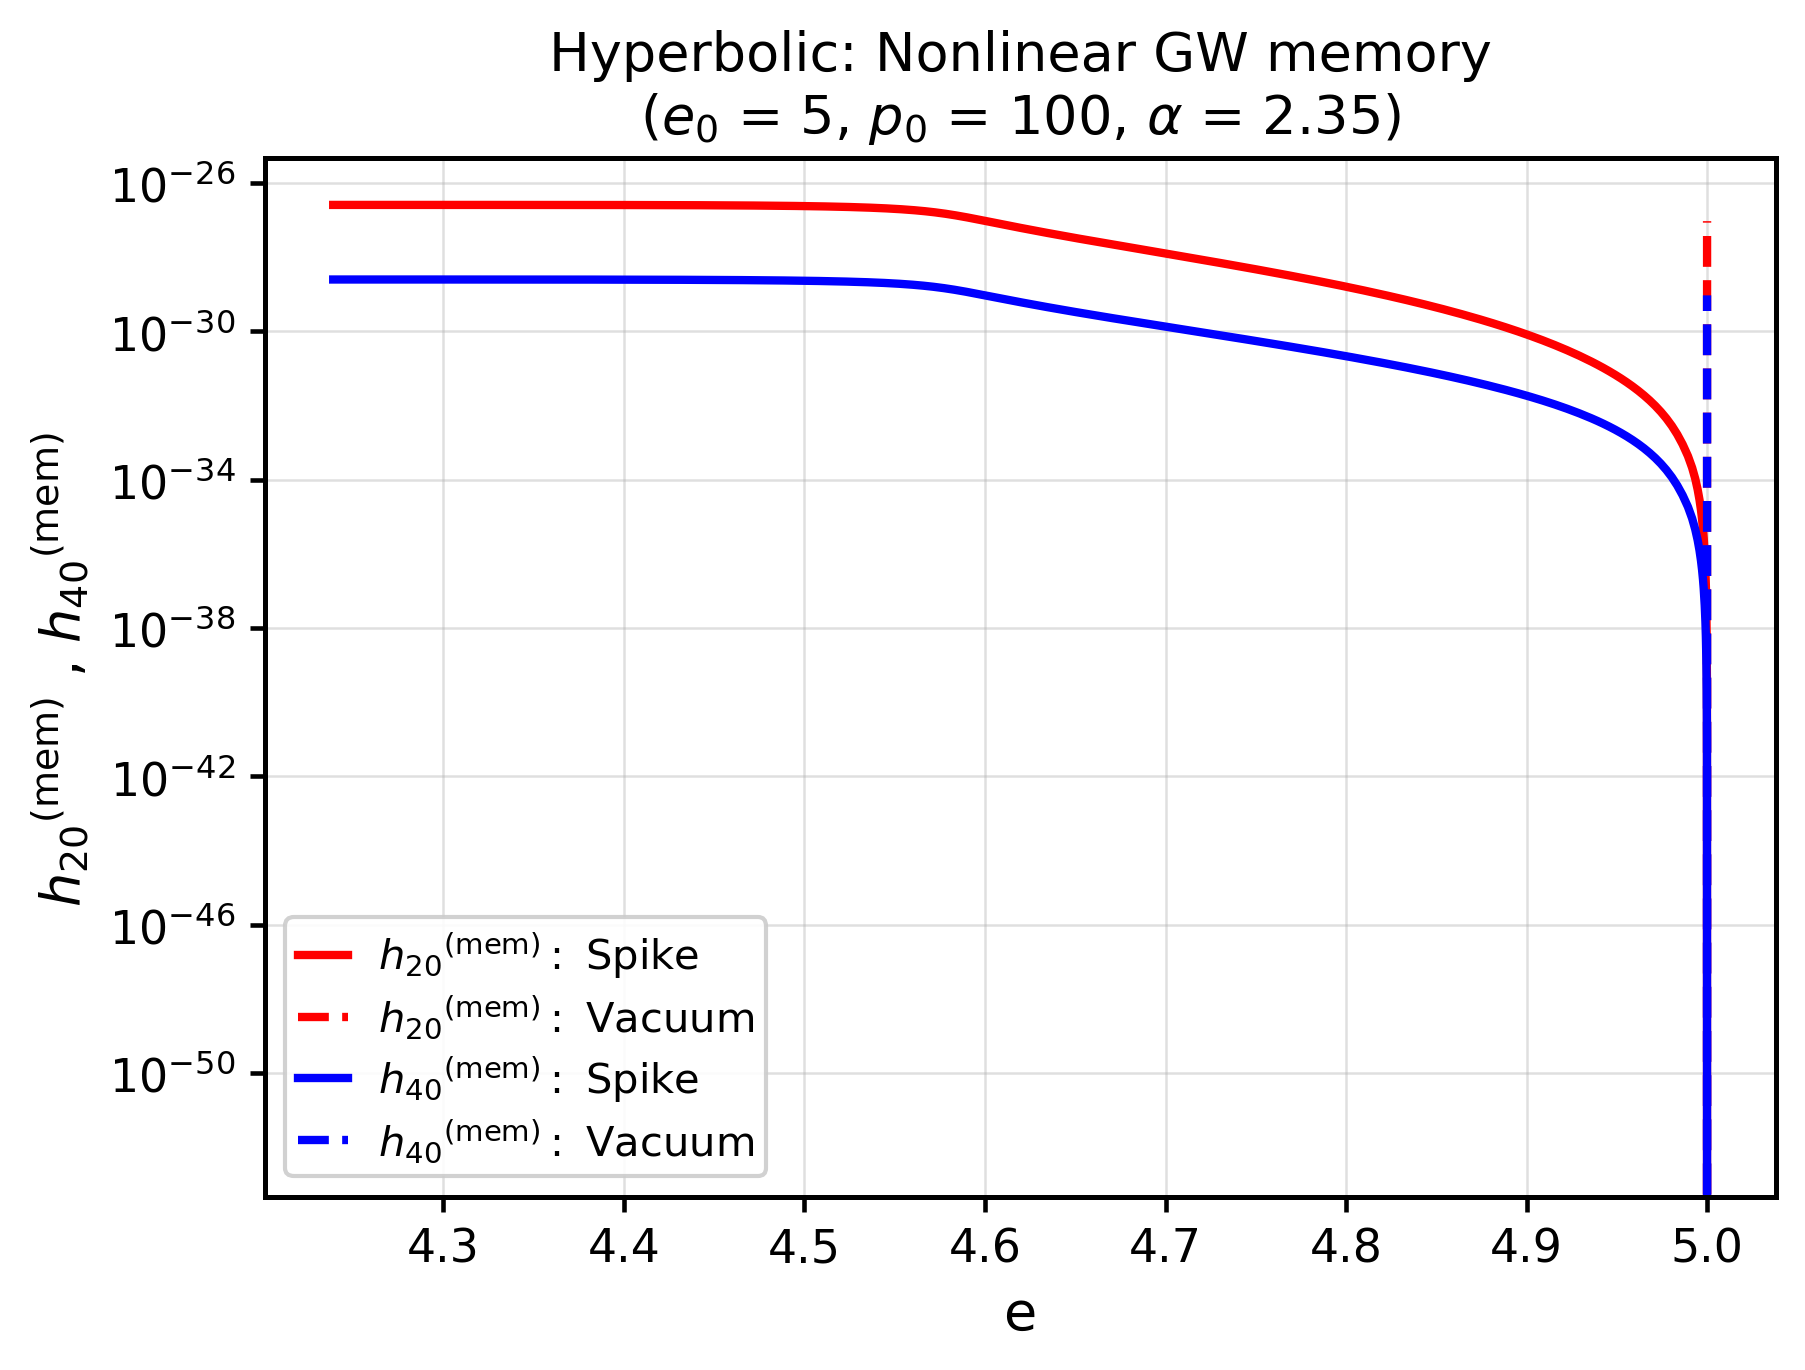

In [22]:
# Plotting
plt.figure()
plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_i}, $p_0$ = {p_i}, '+r'${{\alpha}}$' +f' = {alpha})')

plt.plot( y_net[0,:], h20_mem_NET, label = r' ${h_{20}}^{\text{(mem)}}:$' +' Spike', linestyle='-', color='red' )
plt.plot( ygw[0,:], h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + ' Vacuum', linestyle='--', color='red')

plt.plot( y_net[0,:], h40_mem_NET, label = r' ${h_{40}}^{\text{(mem)}}:$' + ' Spike', linestyle='-', color='blue' )
plt.plot( ygw[0,:], h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}:$' + ' Vacuum', linestyle='--', color='blue')

plt.xlabel('e')
plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Save as PDF
# plt.savefig("hyperbolic_spike_plot_2.pdf", format="pdf", bbox_inches="tight")

plt.show()

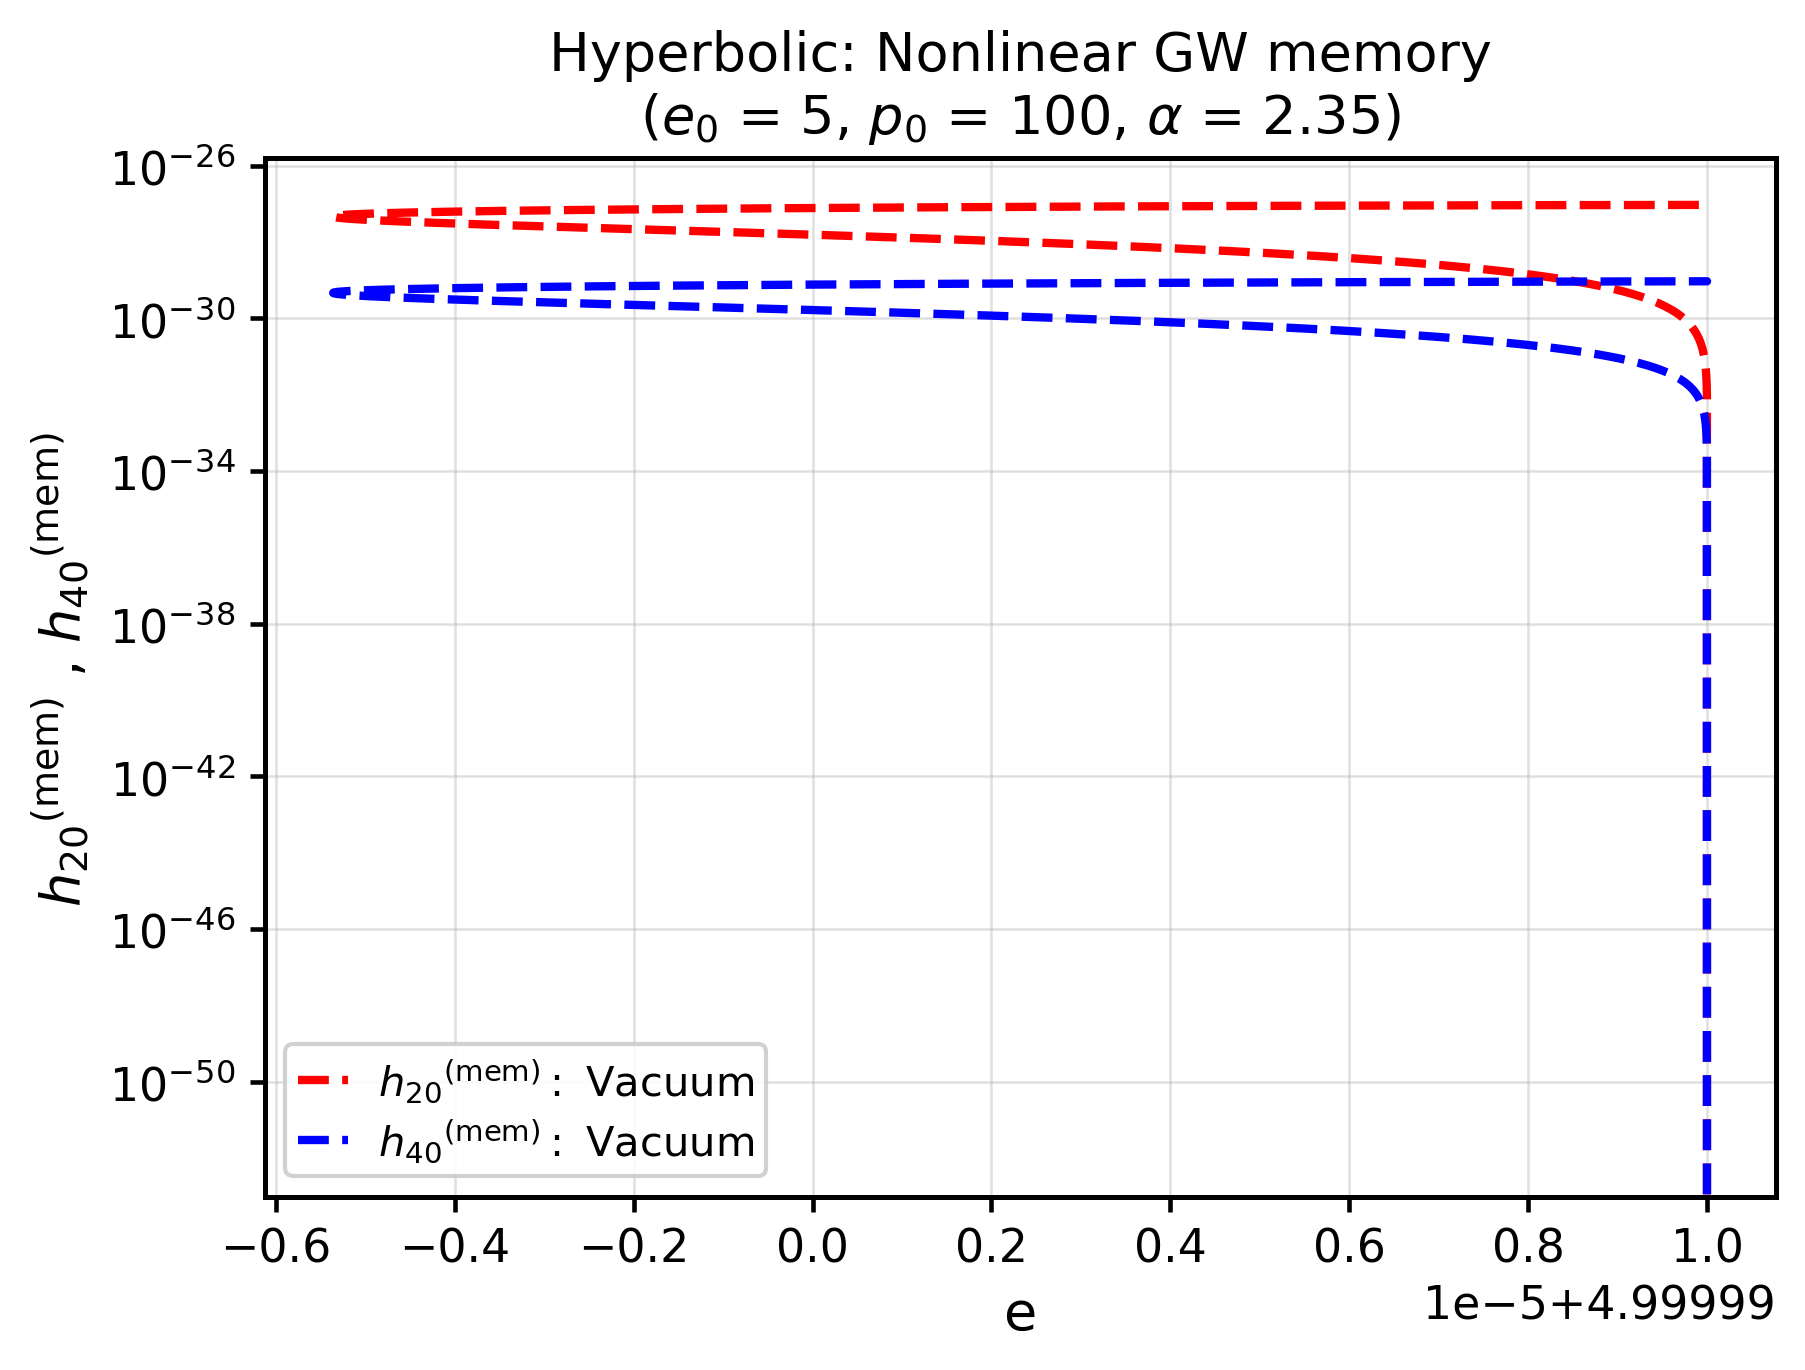

In [23]:
# Plotting
plt.figure()
plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_i}, $p_0$ = {p_i}, '+r'${{\alpha}}$' +f' = {alpha})')

plt.plot( ygw[0,:], h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + ' Vacuum', linestyle='--', color='red')
plt.plot( ygw[0,:], h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}:$' + ' Vacuum', linestyle='--', color='blue')

plt.xlabel('e')
plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Save as PDF
# plt.savefig("hyperbolic_spike_plot_3.pdf", format="pdf", bbox_inches="tight")

plt.show()

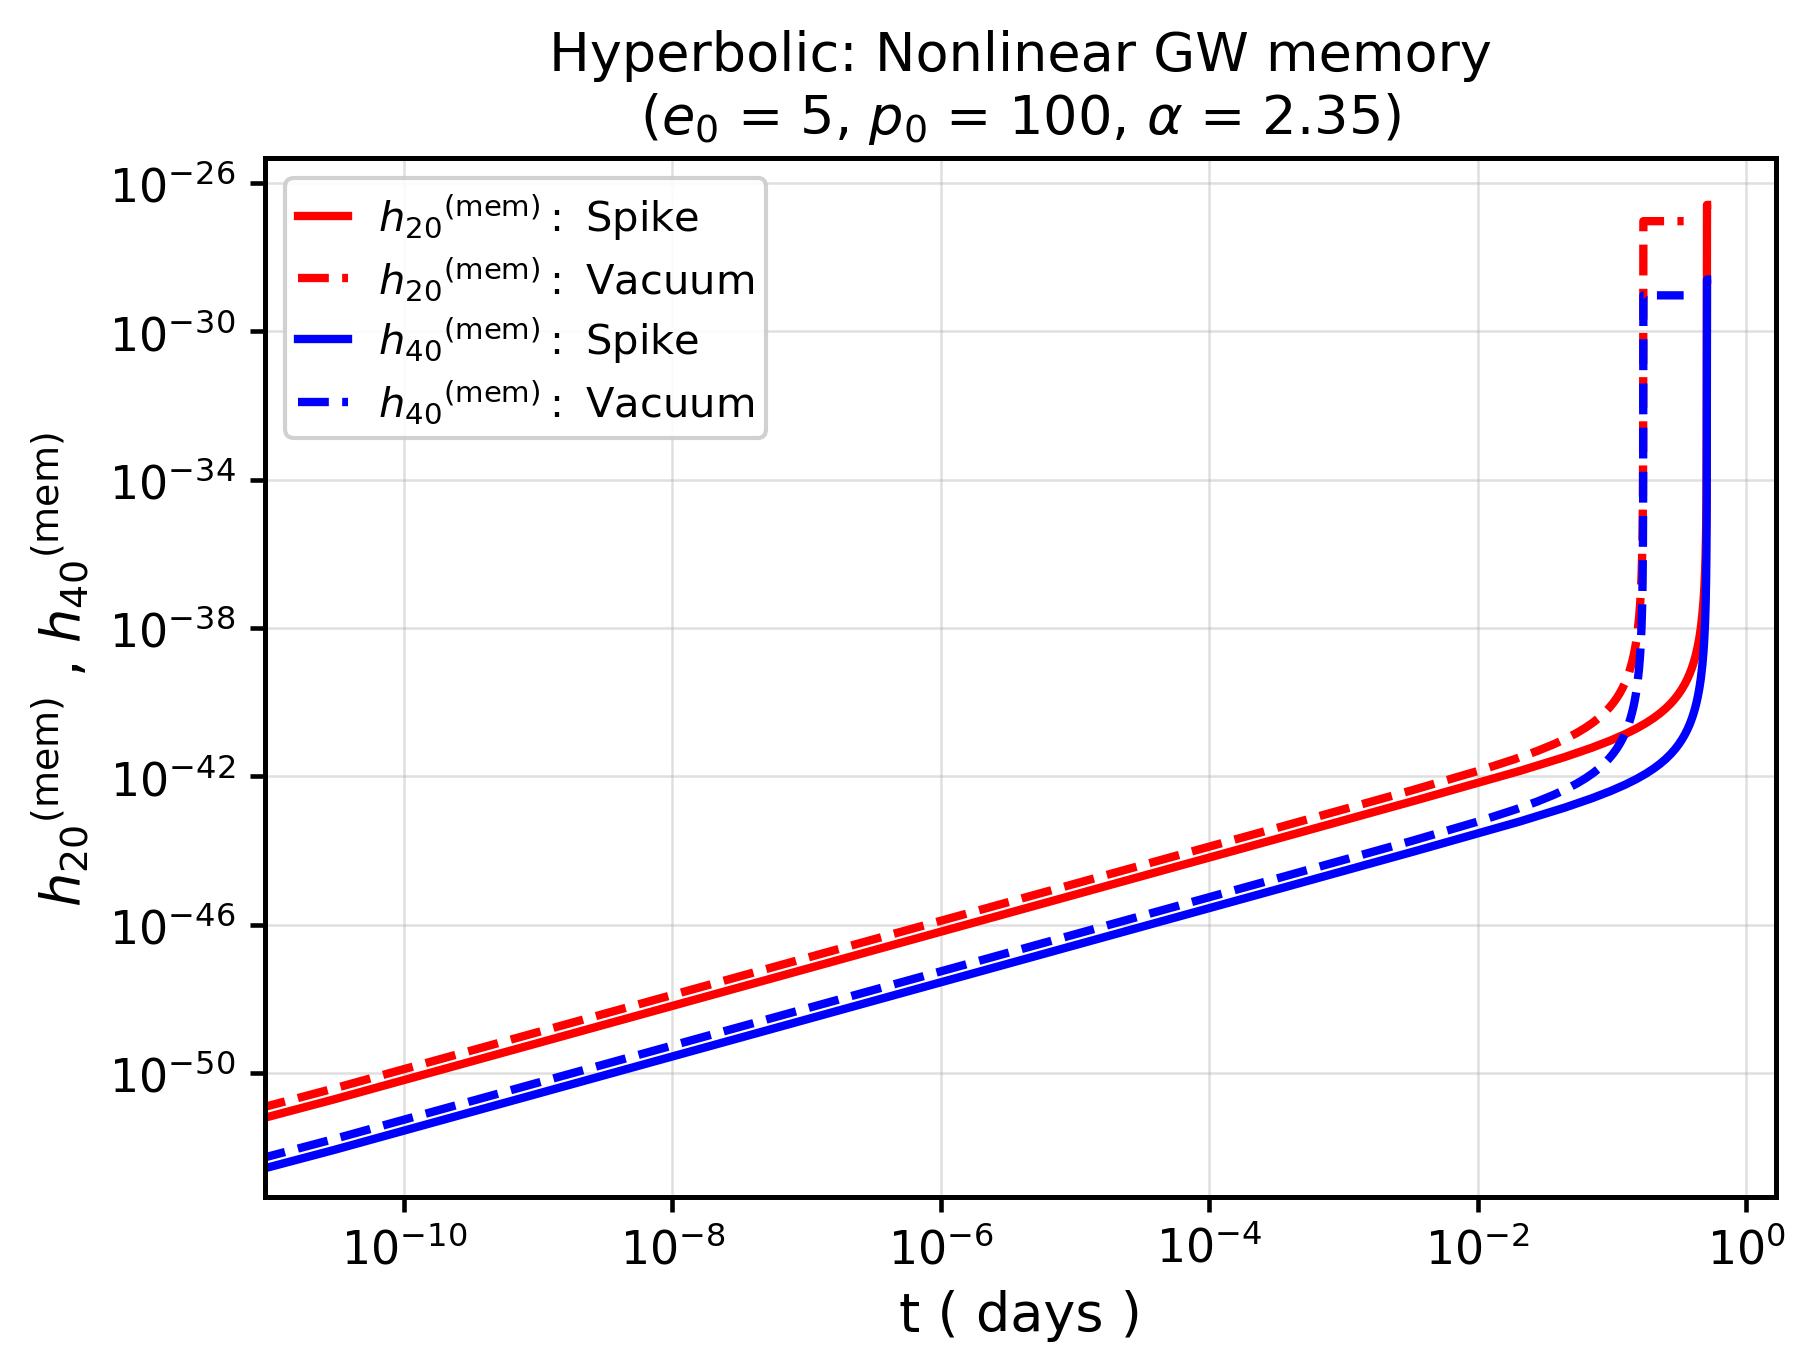

In [24]:
t_day = 24*60*60
# Plotting
plt.figure()
plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_i}, $p_0$ = {p_i}, '+r'${{\alpha}}$' +f' = {alpha})')

plt.plot( y_net[3,:]*t0/t_day, h20_mem_NET, label = r' ${h_{20}}^{\text{(mem)}}:$' +' Spike', linestyle='-', color='red' )
plt.plot( ygw[3,:]*t0/t_day, h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + ' Vacuum', linestyle='--', color='red')

plt.plot( y_net[3,:]*t0/t_day, h40_mem_NET, label = r' ${h_{40}}^{\text{(mem)}}:$' + ' Spike', linestyle='-', color='blue' )
plt.plot( ygw[3,:]*t0/t_day, h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}:$' + ' Vacuum', linestyle='--', color='blue')

plt.xlabel('t ( days )')
plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Save as PDF
# plt.savefig("hyperbolic_spike_plot_4.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### Overall Nonlinear GW memory jump

In [25]:
from scipy.integrate import simpson

# Calculating Overall Nonlinear memory jump for  hl0 (l = 2, 4) modes
def hyperbolic_calculate_overall_nonlinear_memory_jump(e, p_i, alpha, R, val, combination):
    # Staring time
    t_i = 0.0
    
    h20_jump = []
    h40_jump = []
    
    # Calculate nonlinear memory jump for different initial eccentricity
    for i in range(len(e)):
        # Initial value of omega ( angle of closest approach ) (in radians, related to initial eccentricity in hyperbolic case)
        omega_i = round(np.arccos(-1/e[i]),2) 
        
        # ------------------- Orbital evolution -----------------------------------------------------
        if combination==0:
            # GW backrxn only ( For FAVATA result, val=2.5 )    
            sol_without_DM = hyperbolic_orbit_evolution_without_DM(e[i], p_i, omega_i, t_i)
            f, y = sol_without_DM.hyperbolic_orbit_evolution_gw_brxn(val)   
        else:
            # NET : DF + Accretion + DM gravity + GW backrxn
            sol_with_DM = hyperbolic_orbit_evolution_with_DM(e[i], p_i, omega_i, t_i, alpha)
            f, y = sol_with_DM.hyperbolic_orbit_evolution_DM_effect_gw_brxn(val,combination)  

        num = len(f)

        # ----------------- Nonlinear memory calculation --------------------------------------------
        h20dot_mem = dh20dt_mem(y, f, R, alpha, combination, val)
        h40dot_mem = dh40dt_mem(y, f, R, alpha, combination, val)

        dh20df_mem = []
        dh40df_mem = []

        for j in range(num):
            if combination==0:
                # GW backrxn only ( For FAVATA result, val=2.5 ) 
                dedf, dpdf, domegadf, dtdf = hyperbolic_osculating_eqn_gw_brxn(f[j], y[:,j], val, combination, alpha)
                dh20df_mem.append( h20dot_mem[j] * dtdf ) 
                dh40df_mem.append( h40dot_mem[j] * dtdf ) 
            else:
                # NET : Relativistic DF + Accretion + DM gravity + GW backrxn
                dedf, dpdf, domegadf, dtdf = np.add.reduce([hyperbolic_osculating_eqn_gw_brxn(f[j],y[:,j],val,combination,alpha),
                                               hyperbolic_osculating_eqn_DF_accretion(f[j], y[:,j], alpha, combination),
                                               hyperbolic_osculating_eqn_DM_gravity(f[j], y[:,j], alpha, combination)])
                dh20df_mem.append( h20dot_mem[j] * dtdf ) 
                dh40df_mem.append( h40dot_mem[j] * dtdf ) 

        h20_jump.append(simpson(dh20df_mem, f))
        h40_jump.append(simpson(dh40df_mem, f))

    return h20_jump, h40_jump

In [26]:
e = np.linspace(1, 10, 100)  # initial eccentricity array

# Overall nonlinear memory jump for different initial eccentricity

# Only GW backreaction ( FAVATA result )
h20jump_without_DM, h40jump_without_DM = hyperbolic_calculate_overall_nonlinear_memory_jump(e, p_i, alpha, R, val=2.5, combination=0)

# NET : DM gravity + DF + Accretion + GW brxn
h20jump_with_DM, h40jump_with_DM = hyperbolic_calculate_overall_nonlinear_memory_jump(e, p_i, alpha, R, val=0, combination=3)

The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached th

The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached th

In [27]:
# Save array 
np.save("e.npy", e)

%store p_i

# Save array : WITHOUT DM 
np.save("hyp_h20jump_without_DM.npy", h20jump_without_DM)
np.save("hyp_h40jump_without_DM.npy", h40jump_without_DM)

# Save array : WITH DM 
np.save("hyp_h20jump_with_DM_spike.npy", h20jump_with_DM)
np.save("hyp_h40jump_with_DM_spike.npy", h40jump_with_DM)

Stored 'p_i' (int)


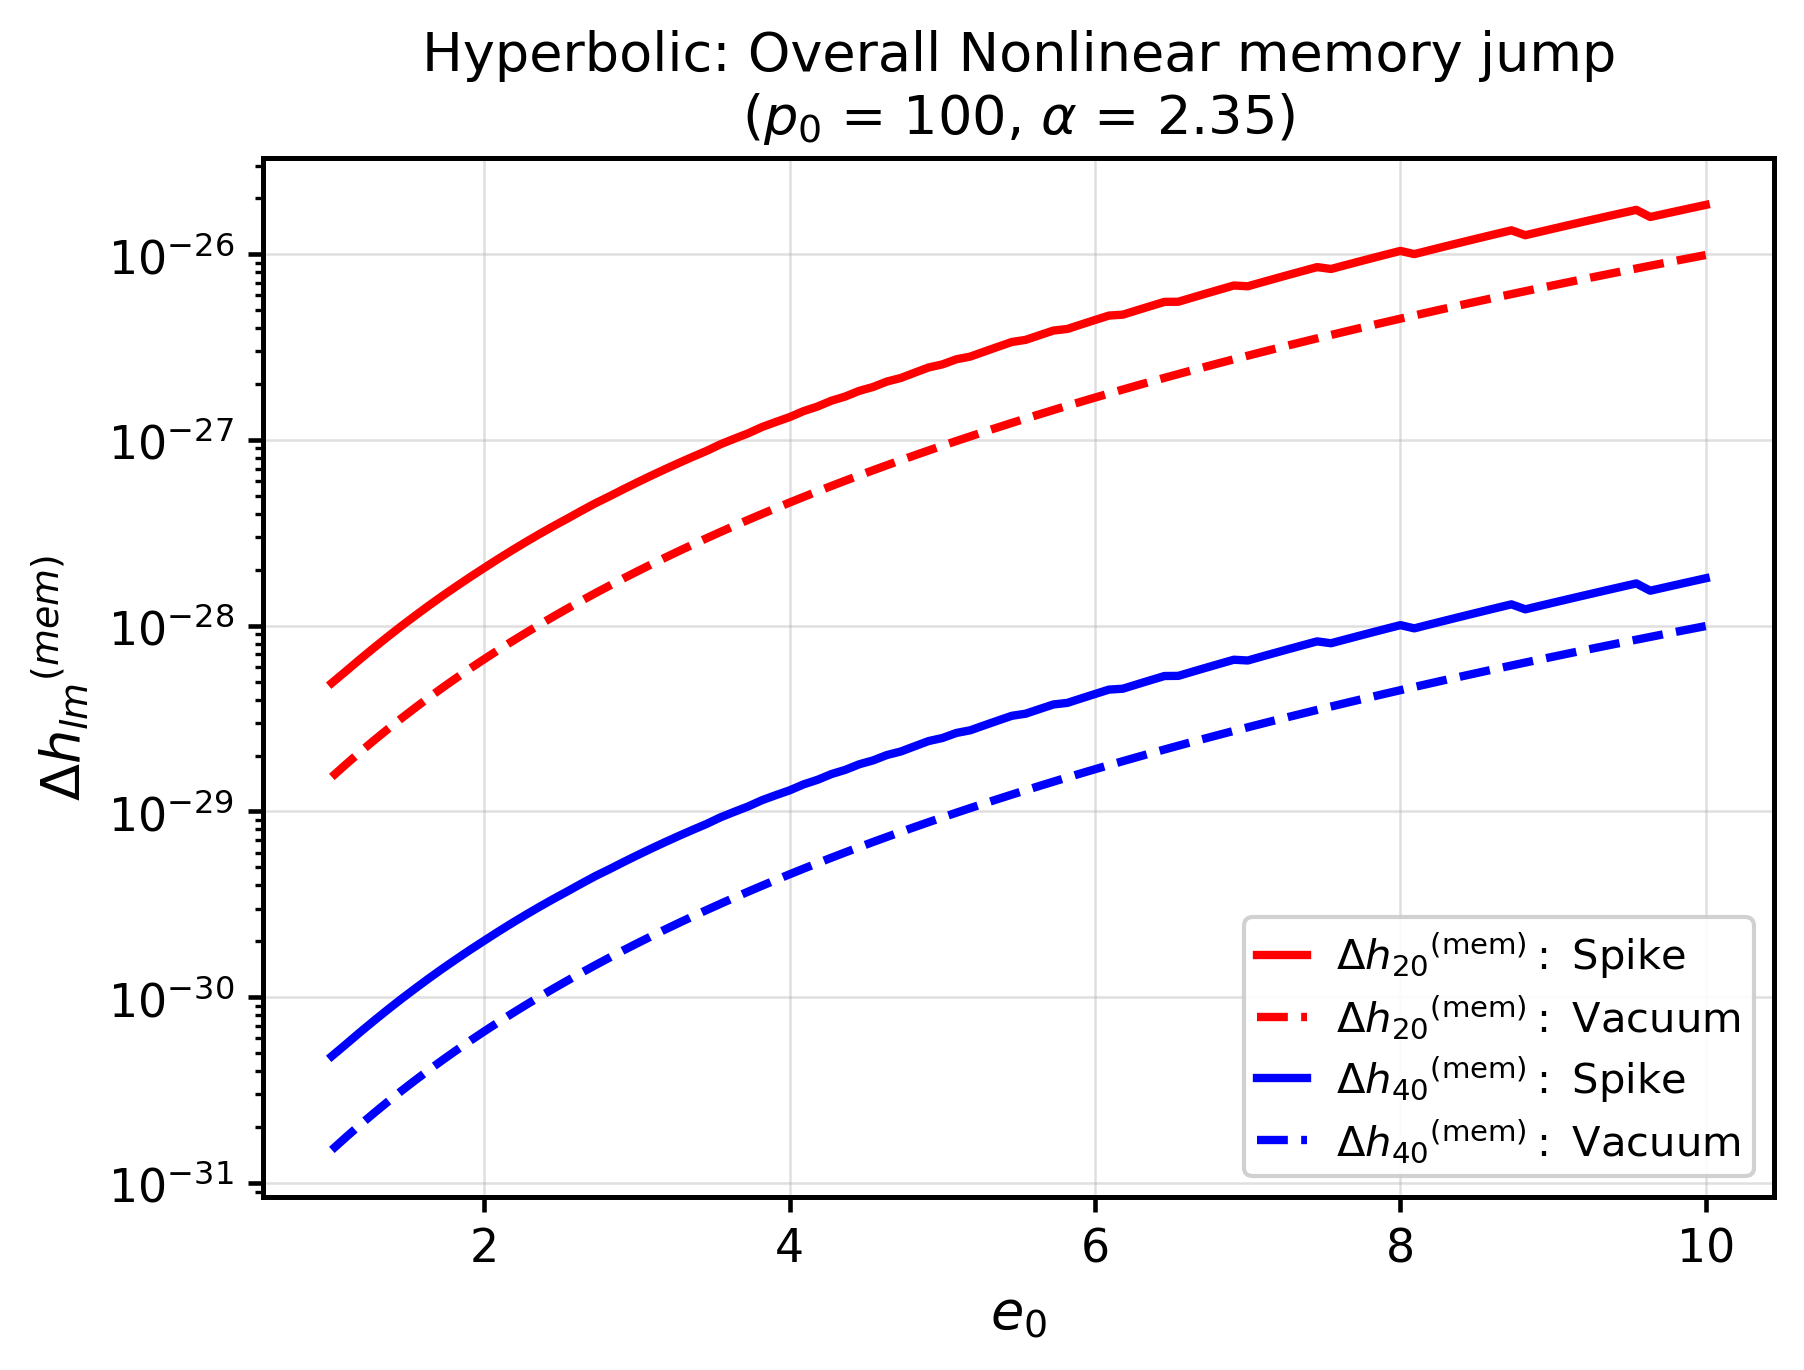

In [28]:
# Plotting
plt.figure()
plt.title('Hyperbolic: Overall Nonlinear memory jump' + "\n" + rf'($p_0$ = {p_i}, '+r'${{\alpha}}$' +f' = {alpha})')

plt.plot( e, h20jump_with_DM, label = r' $\Delta {h_{20}}^{\text{(mem)}}:$' +' Spike', linestyle='-', color='red' )
plt.plot( e, h20jump_without_DM, label= r' $\Delta {h_{20}}^{\text{(mem)}}: $' + ' Vacuum', linestyle='--', color='red')

plt.plot( e, h40jump_with_DM, label = r' $\Delta {h_{40}}^{\text{(mem)}}:$' + ' Spike', linestyle='-', color='blue' )
plt.plot( e, h40jump_without_DM, label= r' $\Delta {h_{40}}^{\text{(mem)}}:$' + ' Vacuum', linestyle='--', color='blue')

plt.xlabel(r'$e_0$')
plt.ylabel(r'$\Delta {h_{lm}}^{(mem)}$')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Save as PDF
# plt.savefig("hyperbolic_spike_plot_5.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### Hyperbolic : Nonlinear memory for different initial eccentricities ( $e_0$ )

The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.


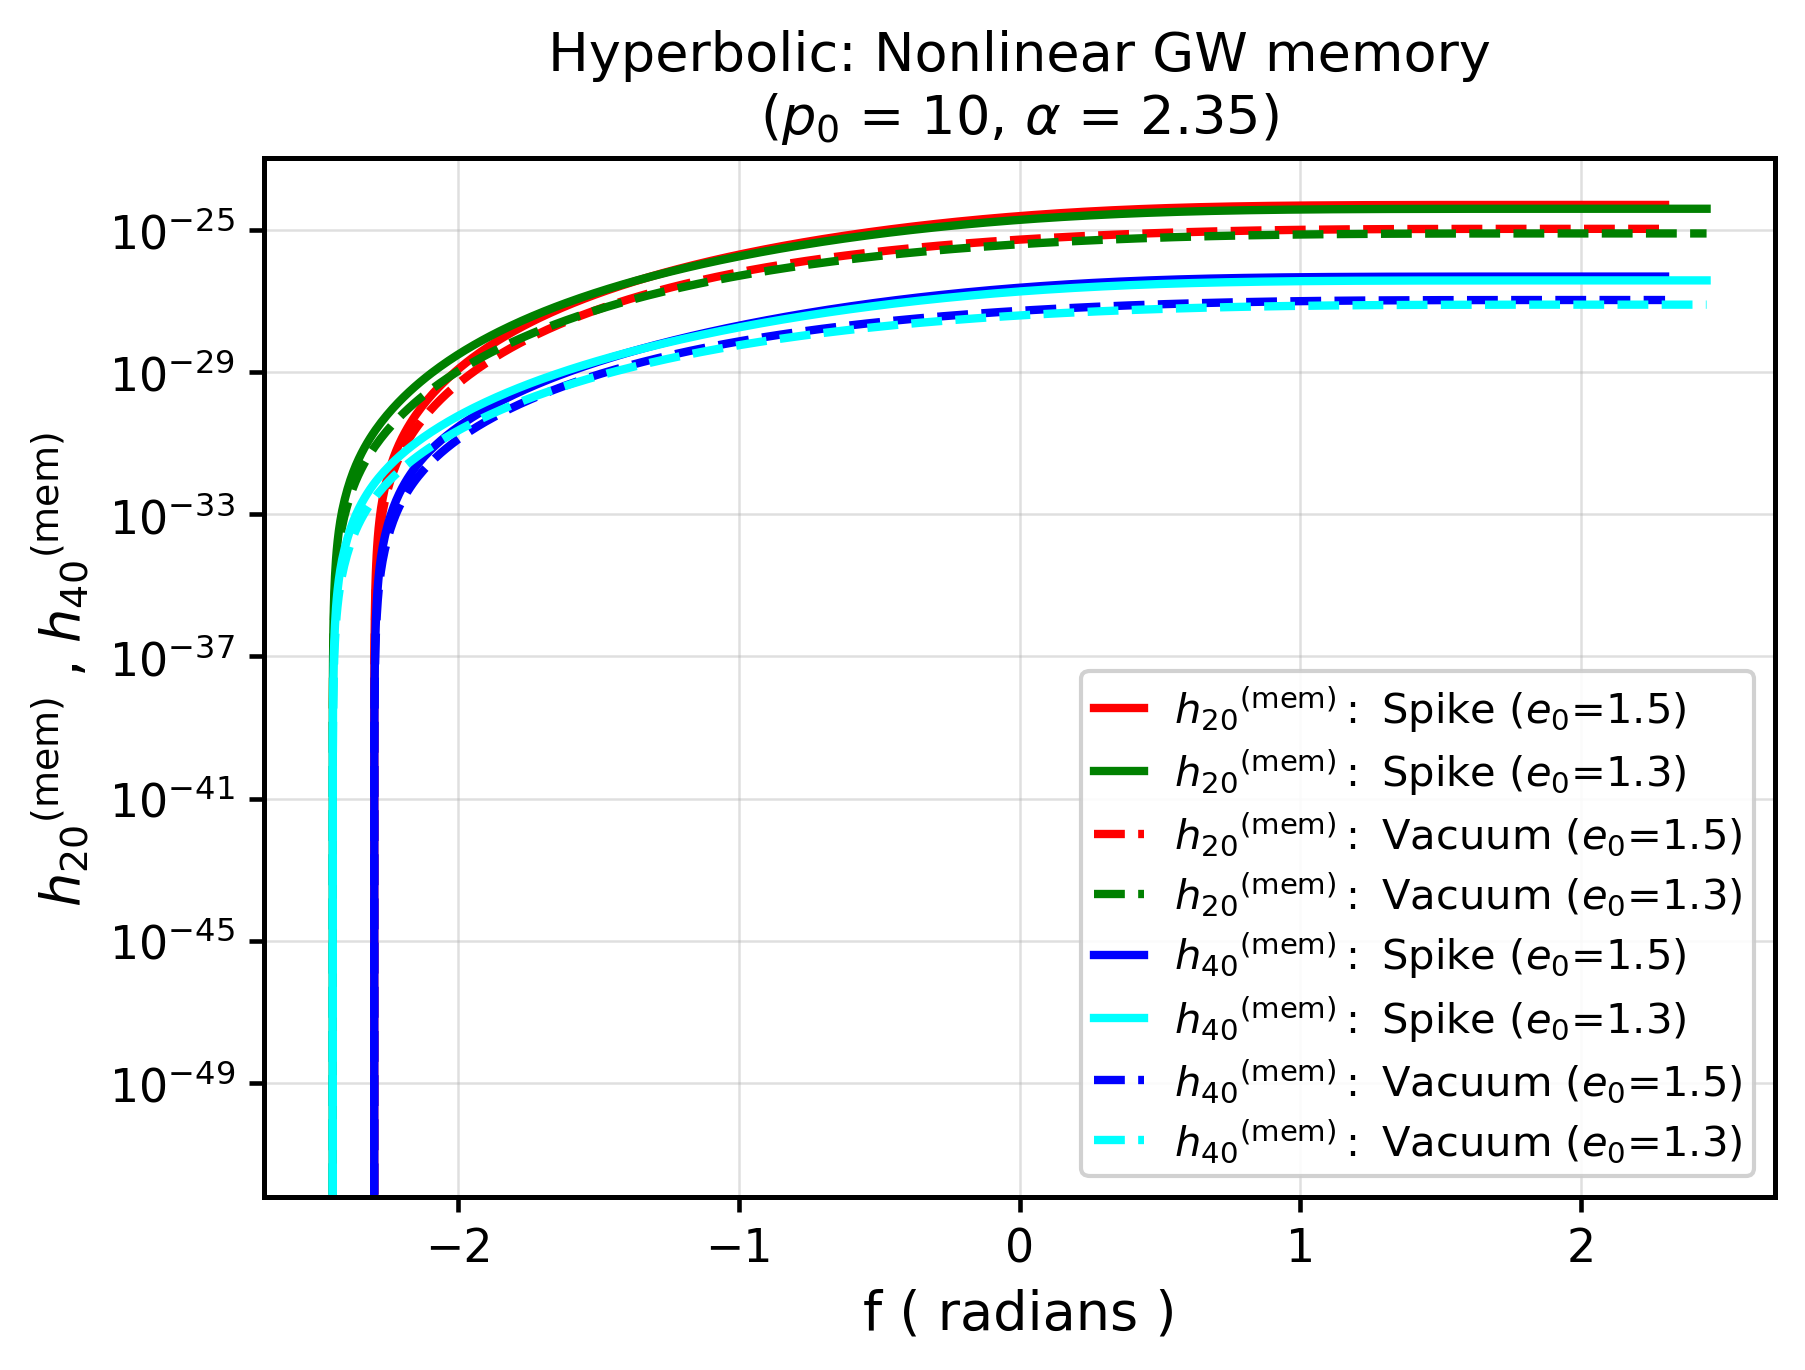

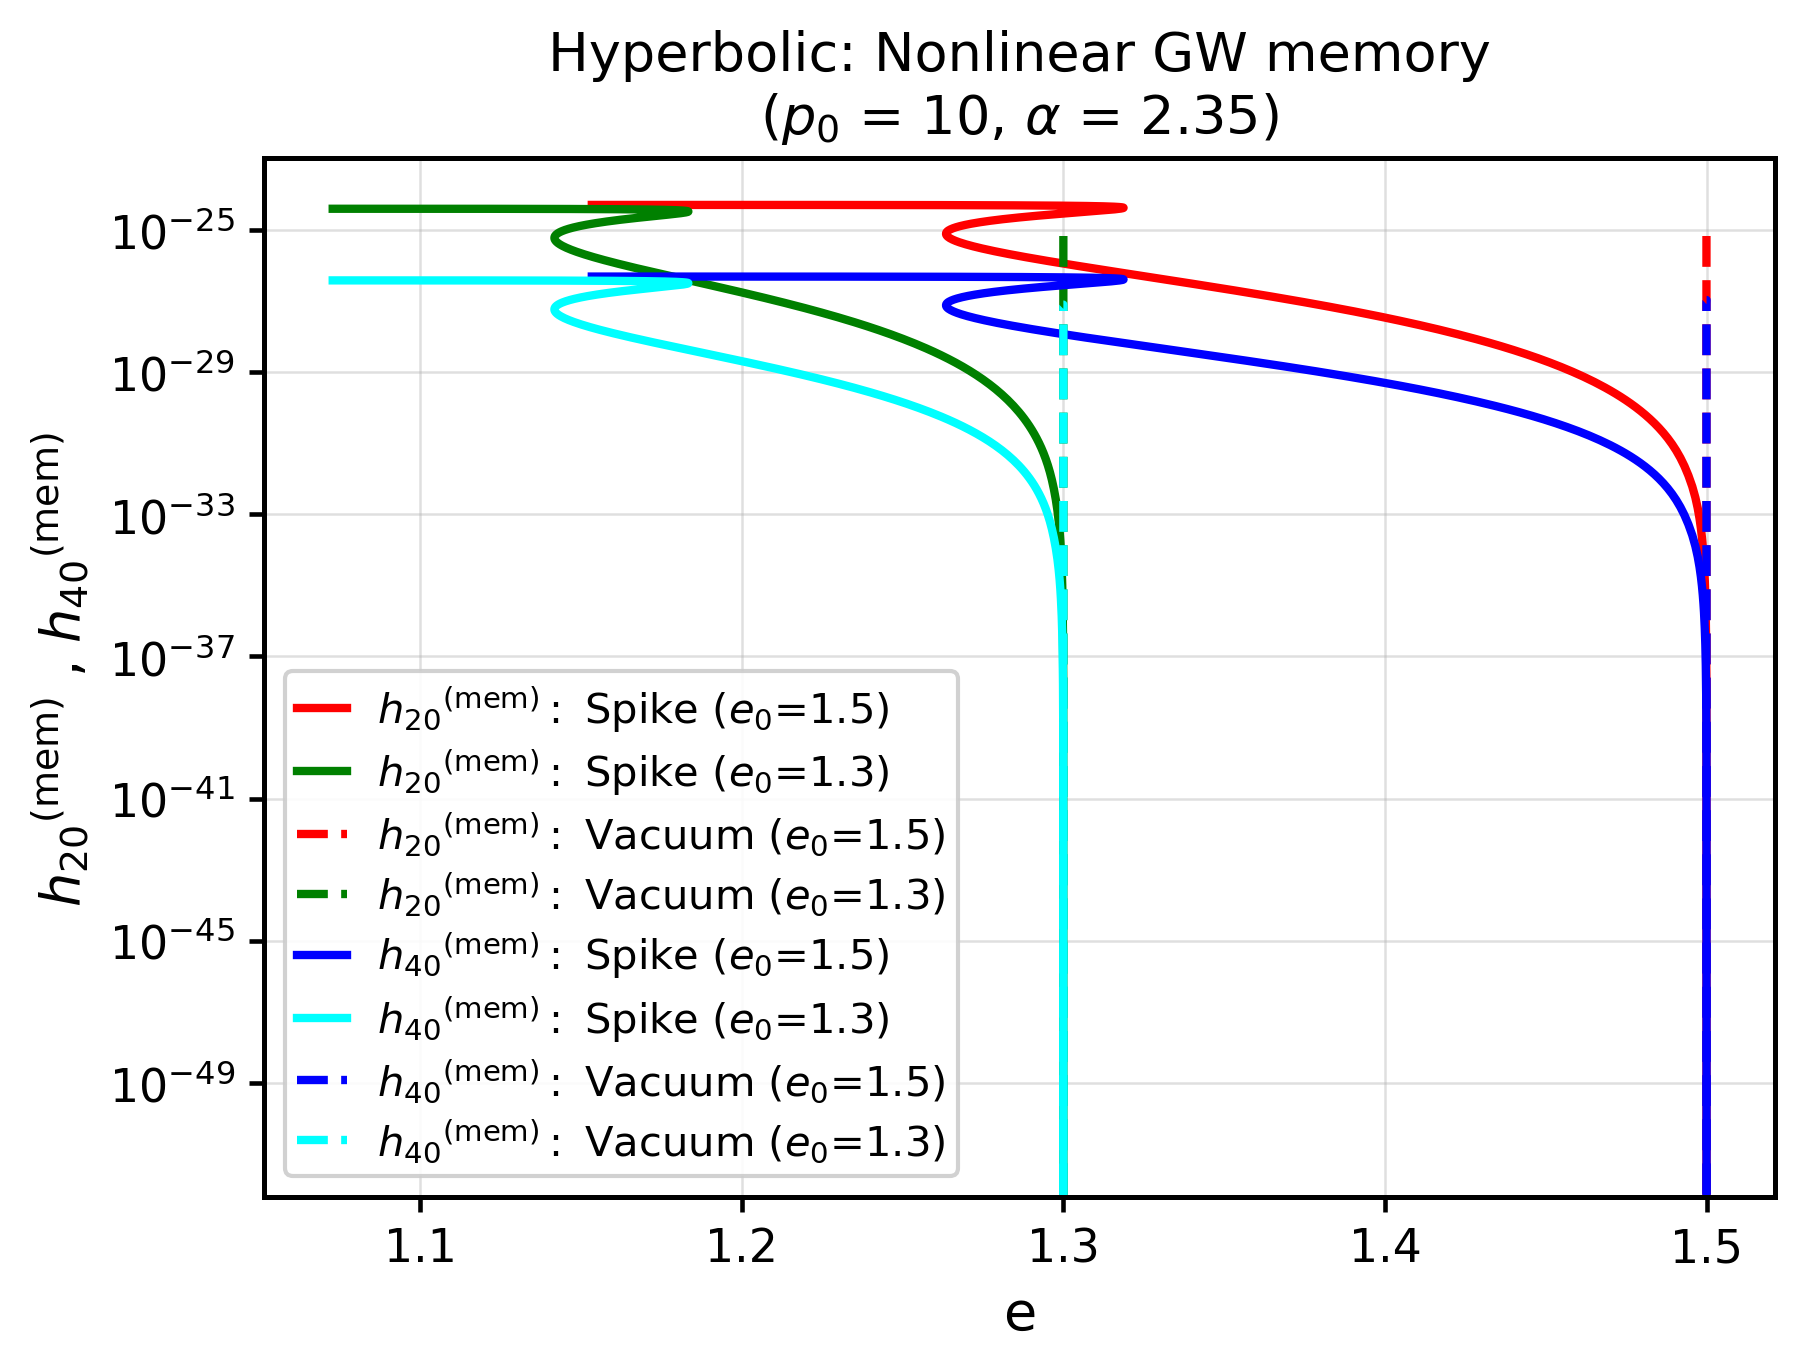

In [29]:
def hyperbolic_nonlinear_memo_diff_init_eccentricities(e_initials, p_0, t_0, alpha, R):
    # initial eccentricities
    e0_1, omega0_1 = e_initials[0], round(np.arccos(-1/e_initials[0]),2)
    e0_2, omega0_2 = e_initials[1], round(np.arccos(-1/e_initials[1]),2)

    # Calculating Nonlinear GW memory for given initial orbital parameters
    hyperbolic_nonlinear_memory1 = hyperbolic_calculate_nonlinear_memory(e0_1, p_0, omega0_1, t_0, alpha, R)
    hyperbolic_nonlinear_memory2 = hyperbolic_calculate_nonlinear_memory(e0_2, p_0, omega0_2, t_0, alpha, R)
    
    # Only GW backreaction
    fgw1, ygw1, h20_mem_gw1, h40_mem_gw1, h22P_mem_gw1, h22M_mem_gw1 = hyperbolic_nonlinear_memory1.cal_hl0(val=2.5, combination=0)
    fgw2, ygw2, h20_mem_gw2, h40_mem_gw2, h22P_mem_gw2, h22M_mem_gw2 = hyperbolic_nonlinear_memory2.cal_hl0(val=2.5, combination=0)
    
    # NET : DM gravity + Relativistic DF + Accretion + GW brxn
    f_net1, y_net1, h20_mem_NET1, h40_mem_NET1, h22P_mem_NET1, h22M_mem_NET1 = hyperbolic_nonlinear_memory1.cal_hl0(val=0, combination=3)
    f_net2, y_net2, h20_mem_NET2, h40_mem_NET2, h22P_mem_NET2, h22M_mem_NET2 = hyperbolic_nonlinear_memory2.cal_hl0(val=0, combination=3)
    
    # Plotting Nonlinear memory VS True anomaly
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($p_0$ = {p_0}, '+r'${{\alpha}}$' +f' = {alpha})')
    
    plt.plot( f_net1, h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_1})', linestyle='-', color='red' )
    plt.plot( f_net2, h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_2})', linestyle='-', color='green' )
    
    plt.plot( fgw1, h20_mem_gw1, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_1})', linestyle='--', color='red')
    plt.plot( fgw2, h20_mem_gw2, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_2})', linestyle='--', color='green')
    
    plt.plot( f_net1, h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_1})', linestyle='-', color='blue' )
    plt.plot( f_net2, h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +f' Spike ($e_0$={e0_2})', linestyle='-', color='cyan' )
    
    plt.plot( fgw1, h40_mem_gw1, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_1})', linestyle='--', color='blue')
    plt.plot( fgw2, h40_mem_gw2, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_2})', linestyle='--', color='cyan')
    
    plt.xlabel('f ( radians )')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    plt.savefig("hyperbolic_spike_plot_6.pdf", format="pdf", bbox_inches="tight")

    plt.show()
        
    # Plotting Nonlinear memory VS eccentricity
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($p_0$ = {p_0}, '+r'${{\alpha}}$' +f' = {alpha})')
    
    plt.plot( y_net1[0,:], h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_1})', linestyle='-', color='red' )
    plt.plot( y_net2[0,:], h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_2})', linestyle='-', color='green' )
    
    plt.plot( ygw1[0,:], h20_mem_gw1, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_1})', linestyle='--', color='red')
    plt.plot( ygw2[0,:], h20_mem_gw2, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_2})', linestyle='--', color='green')
    
    plt.plot( y_net1[0,:], h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_1})', linestyle='-', color='blue' )
    plt.plot( y_net2[0,:], h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($e_0$={e0_2})', linestyle='-', color='cyan' )
    
    plt.plot( ygw1[0,:], h40_mem_gw1, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_1})', linestyle='--', color='blue')
    plt.plot( ygw2[0,:], h40_mem_gw2, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($e_0$={e0_2})', linestyle='--', color='cyan')
    
    plt.xlabel('e')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    # plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    # plt.savefig("hyperbolic_spike_plot_7.pdf", format="pdf", bbox_inches="tight")

    plt.show()

# Initial orbital parameters
e_initials = [1.5, 1.3] # initial eccentricities
p0, t0 = 10, 0.0

# Plotting Nonlinear memory for three-different initial eccentricities
hyperbolic_nonlinear_memo_diff_init_eccentricities(e_initials, p0, t0, alpha, R)

#### Hyperbolic : Nonlinear memory for different initial semi-latus rectum ( $p_0$ )

The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.


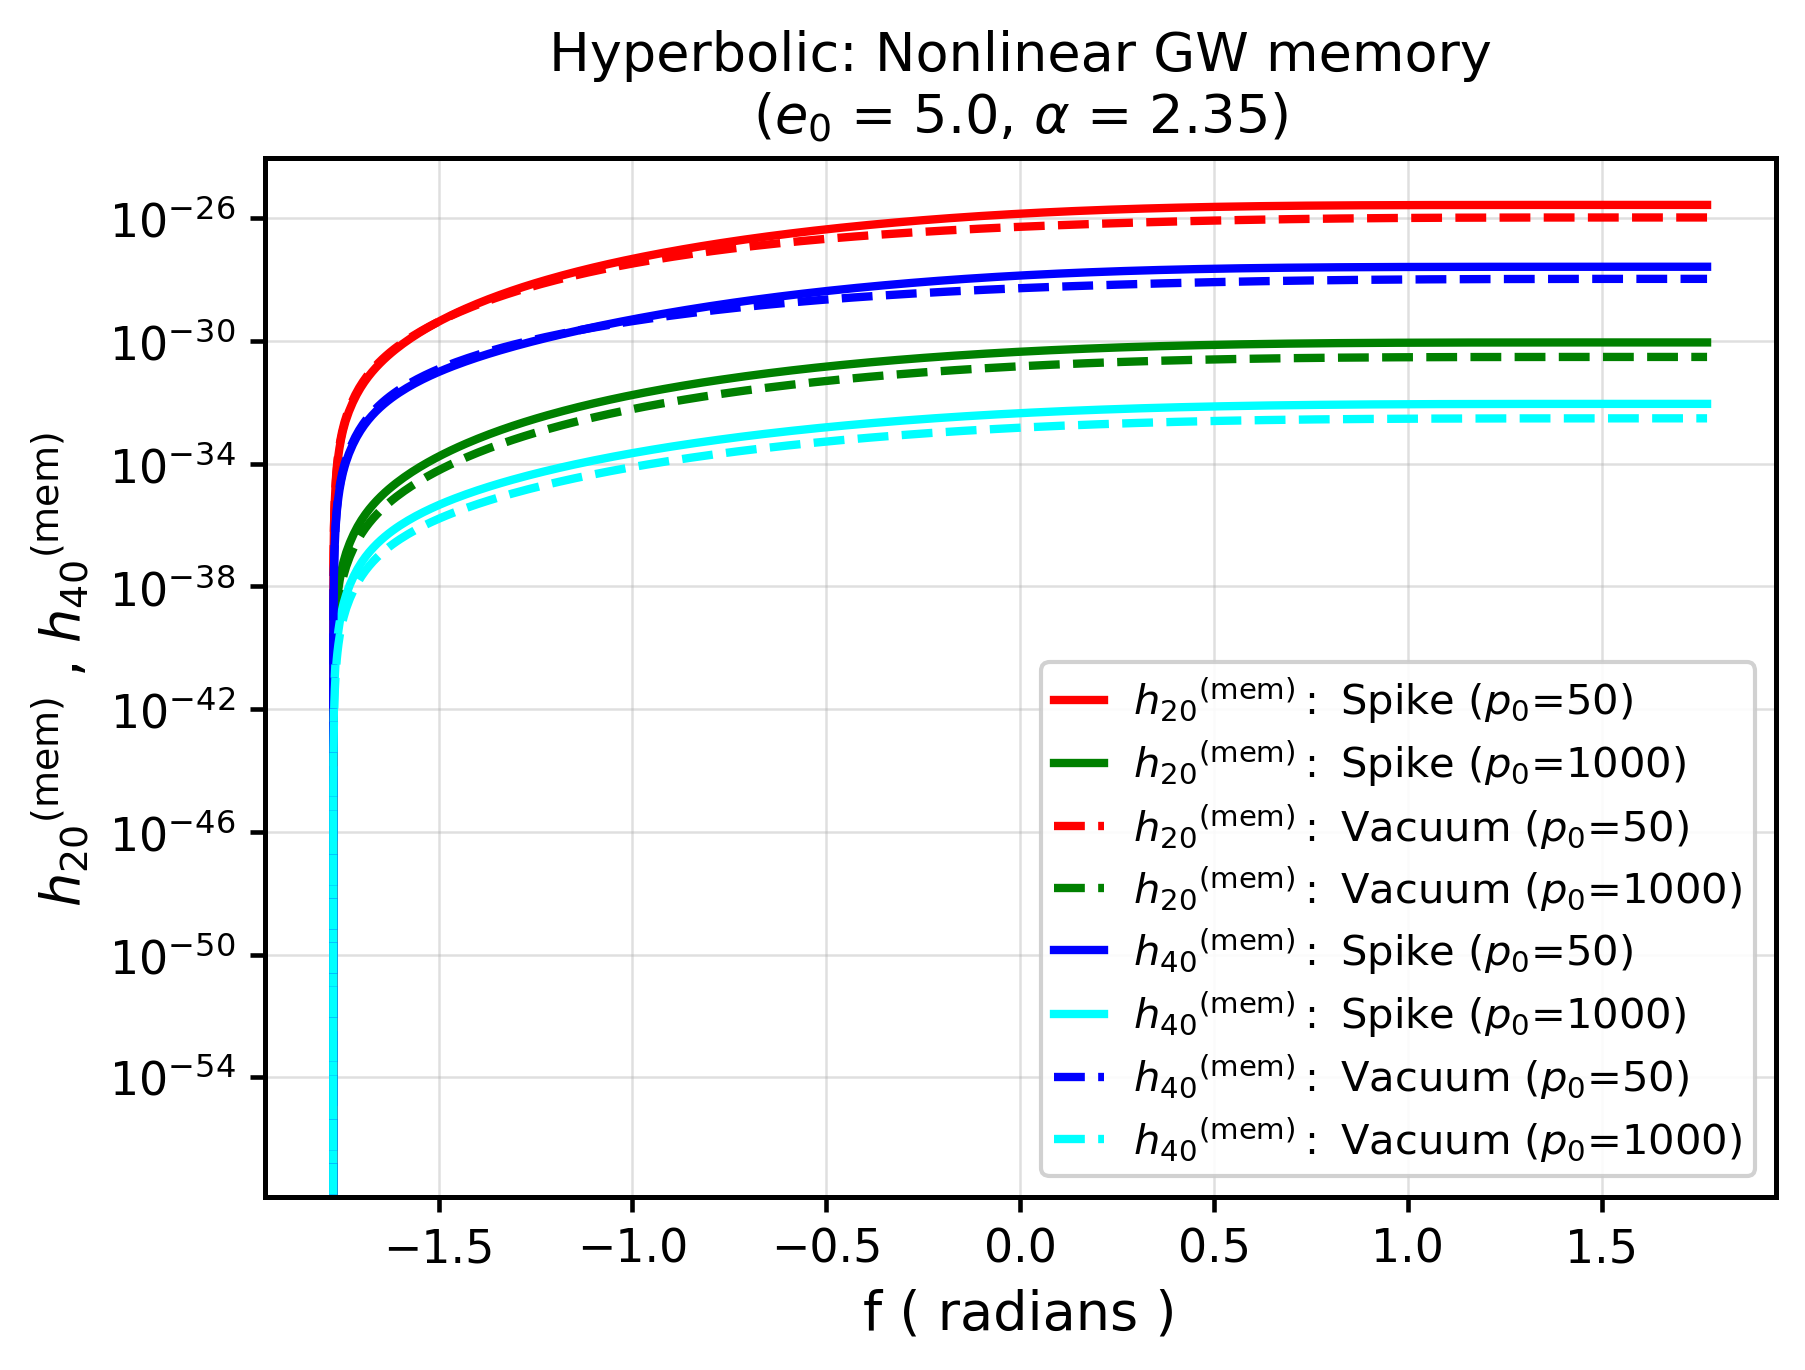

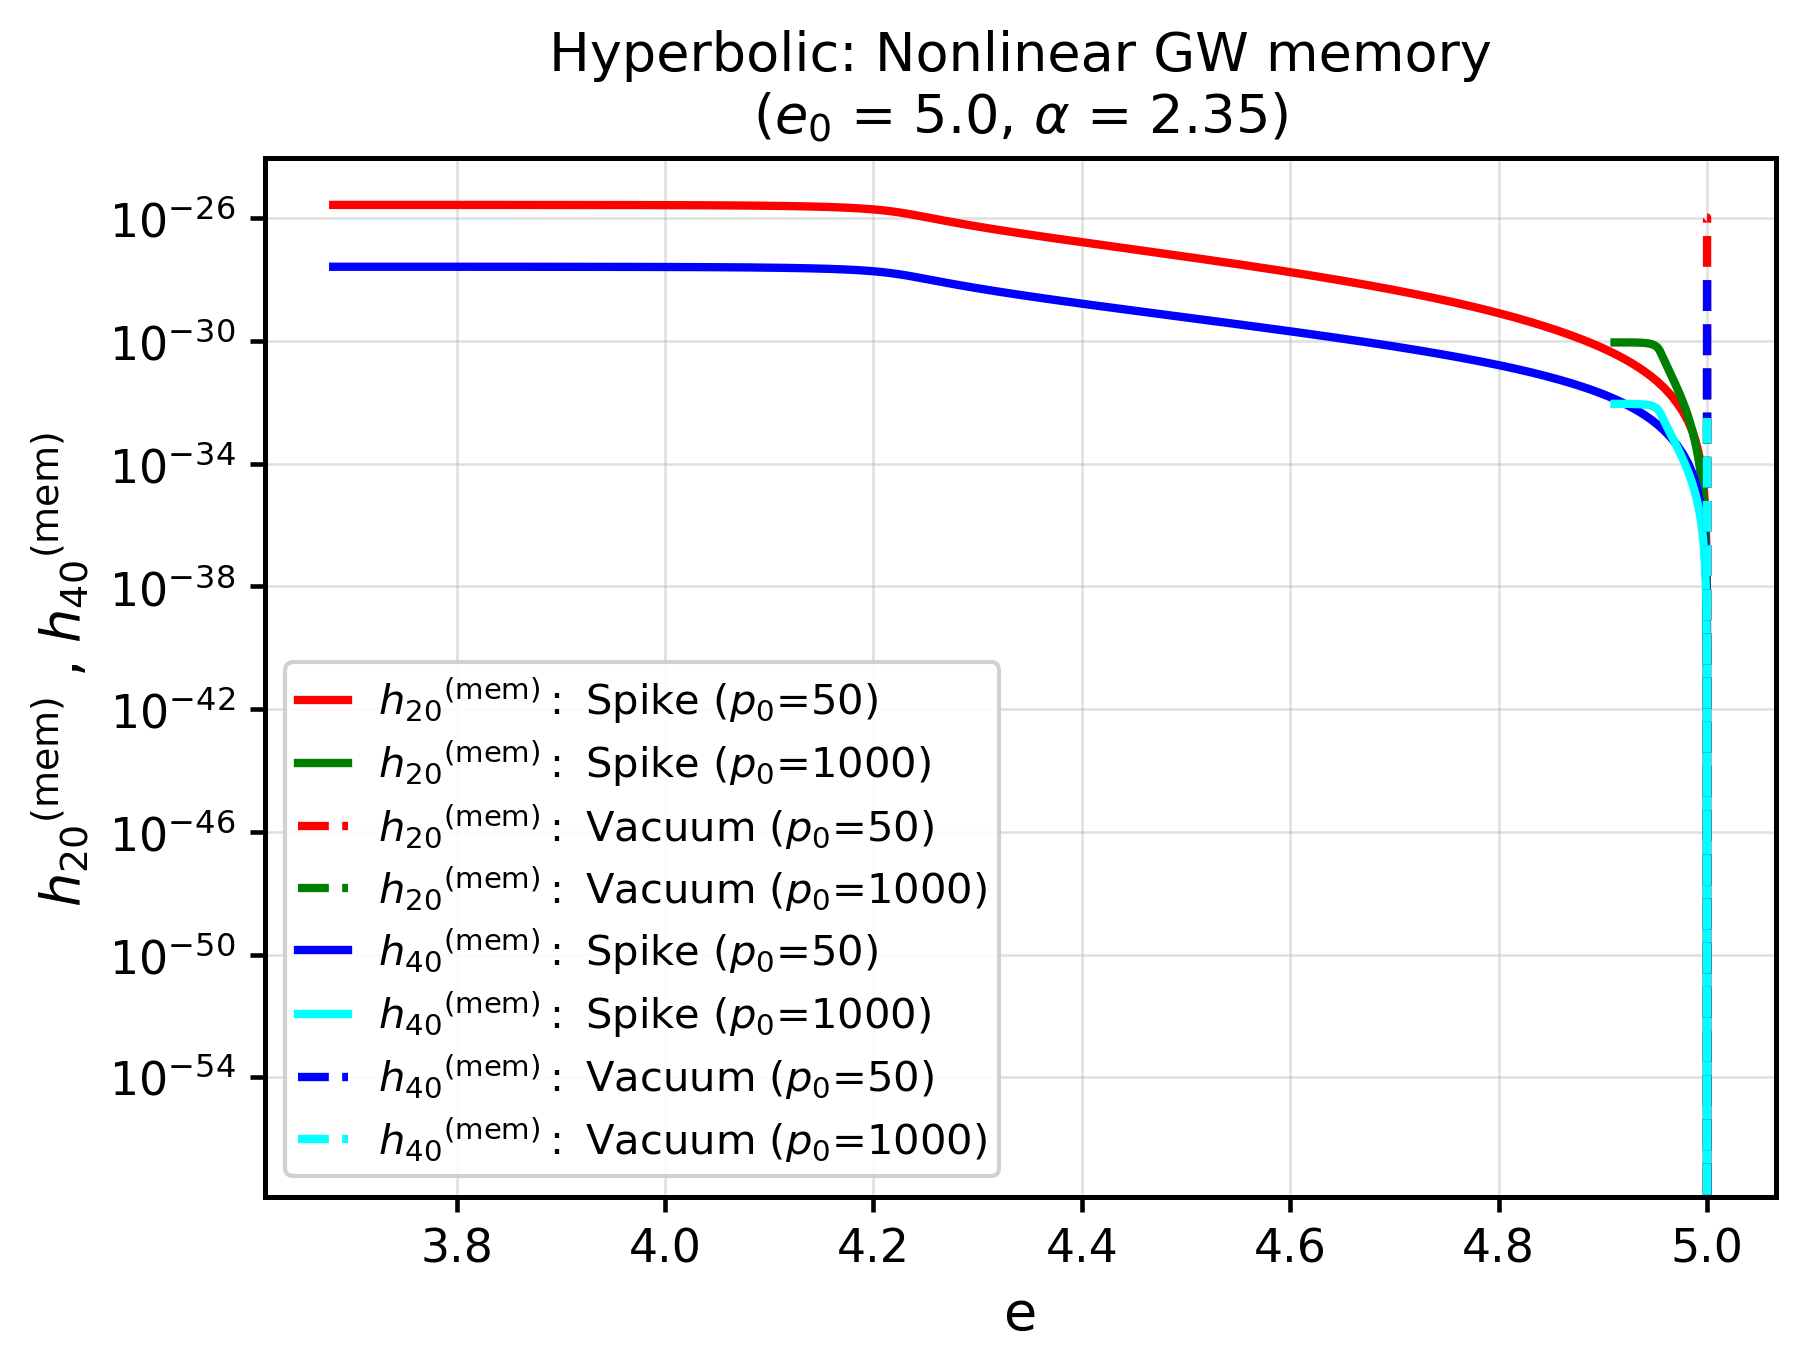

In [30]:
def hyperbolic_nonlinear_memo_diff_init_p(e_0, p_initials, omega_0, t_0, alpha, R):
    # initial semi-latus rectum values
    p0_1 = p_initials[0] 
    p0_2 = p_initials[1] 

    # Calculating Nonlinear GW memory for given initial orbital parameters
    hyperbolic_nonlinear_memory1 = hyperbolic_calculate_nonlinear_memory(e_0, p0_1, omega_0, t_0, alpha, R)
    hyperbolic_nonlinear_memory2 = hyperbolic_calculate_nonlinear_memory(e_0, p0_2, omega_0, t_0, alpha, R)
    
    # Only GW backreaction
    fgw1, ygw1, h20_mem_gw1, h40_mem_gw1, h22P_mem_gw1, h22M_mem_gw1 = hyperbolic_nonlinear_memory1.cal_hl0(val=2.5, combination=0)
    fgw2, ygw2, h20_mem_gw2, h40_mem_gw2, h22P_mem_gw2, h22M_mem_gw2 = hyperbolic_nonlinear_memory2.cal_hl0(val=2.5, combination=0)
    
    # NET : DM gravity + Relativistic DF + Accretion + GW brxn
    f_net1, y_net1, h20_mem_NET1, h40_mem_NET1, h22P_mem_NET1, h22M_mem_NET1 = hyperbolic_nonlinear_memory1.cal_hl0(val=0, combination=3)
    f_net2, y_net2, h20_mem_NET2, h40_mem_NET2, h22P_mem_NET2, h22M_mem_NET2 = hyperbolic_nonlinear_memory2.cal_hl0(val=0, combination=3)
    
    # Plotting Nonlinear memory VS True anomaly
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_0}, '+r'${{\alpha}}$' +f' = {alpha})')
    
    plt.plot( f_net1, h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_1})', linestyle='-', color='red' )
    plt.plot( f_net2, h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_2})', linestyle='-', color='green' )
    
    plt.plot( fgw1, h20_mem_gw1, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_1})', linestyle='--', color='red')
    plt.plot( fgw2, h20_mem_gw2, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_2})', linestyle='--', color='green')
    
    plt.plot( f_net1, h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_1})', linestyle='-', color='blue' )
    plt.plot( f_net2, h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_2})', linestyle='-', color='cyan' )
    
    plt.plot( fgw1, h40_mem_gw1, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_1})', linestyle='--', color='blue')
    plt.plot( fgw2, h40_mem_gw2, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_2})', linestyle='--', color='cyan')
    
    plt.xlabel('f ( radians )')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    plt.savefig("hyperbolic_spike_plot_8.pdf", format="pdf", bbox_inches="tight")

    plt.show()
        
    # Plotting Nonlinear memory VS eccentricity
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_0}, '+r'${{\alpha}}$' +f' = {alpha})')
    
    plt.plot( y_net1[0,:], h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_1})', linestyle='-', color='red' )
    plt.plot( y_net2[0,:], h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_2})', linestyle='-', color='green' )
    
    plt.plot( ygw1[0,:], h20_mem_gw1, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_1})', linestyle='--', color='red')
    plt.plot( ygw2[0,:], h20_mem_gw2, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_2})', linestyle='--', color='green')
    
    plt.plot( y_net1[0,:], h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_1})', linestyle='-', color='blue' )
    plt.plot( y_net2[0,:], h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($p_0$={p0_2})', linestyle='-', color='cyan' )
    
    plt.plot( ygw1[0,:], h40_mem_gw1, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_1})', linestyle='--', color='blue')
    plt.plot( ygw2[0,:], h40_mem_gw2, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum ($p_0$={p0_2})', linestyle='--', color='cyan')
    
    plt.xlabel('e')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    # plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    # plt.savefig("hyperbolic_spike_plot_9.pdf", format="pdf", bbox_inches="tight")

    plt.show()

# Initial orbital parameters
p_initials = [50, 1000] # initial semi-latus rectum values
e0, t0 = 5.0, 0.0
omega0 = round(np.arccos(-1/e0),2)

# Plotting Nonlinear memory for three-different initial semi-latus rectum values
hyperbolic_nonlinear_memo_diff_init_p(e0, p_initials, omega0, t0, alpha, R)

#### Hyperbolic : Nonlinear memory for different Static DM exponent ($\alpha$) values

The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.
The solver successfully reached the end of the integration interval.


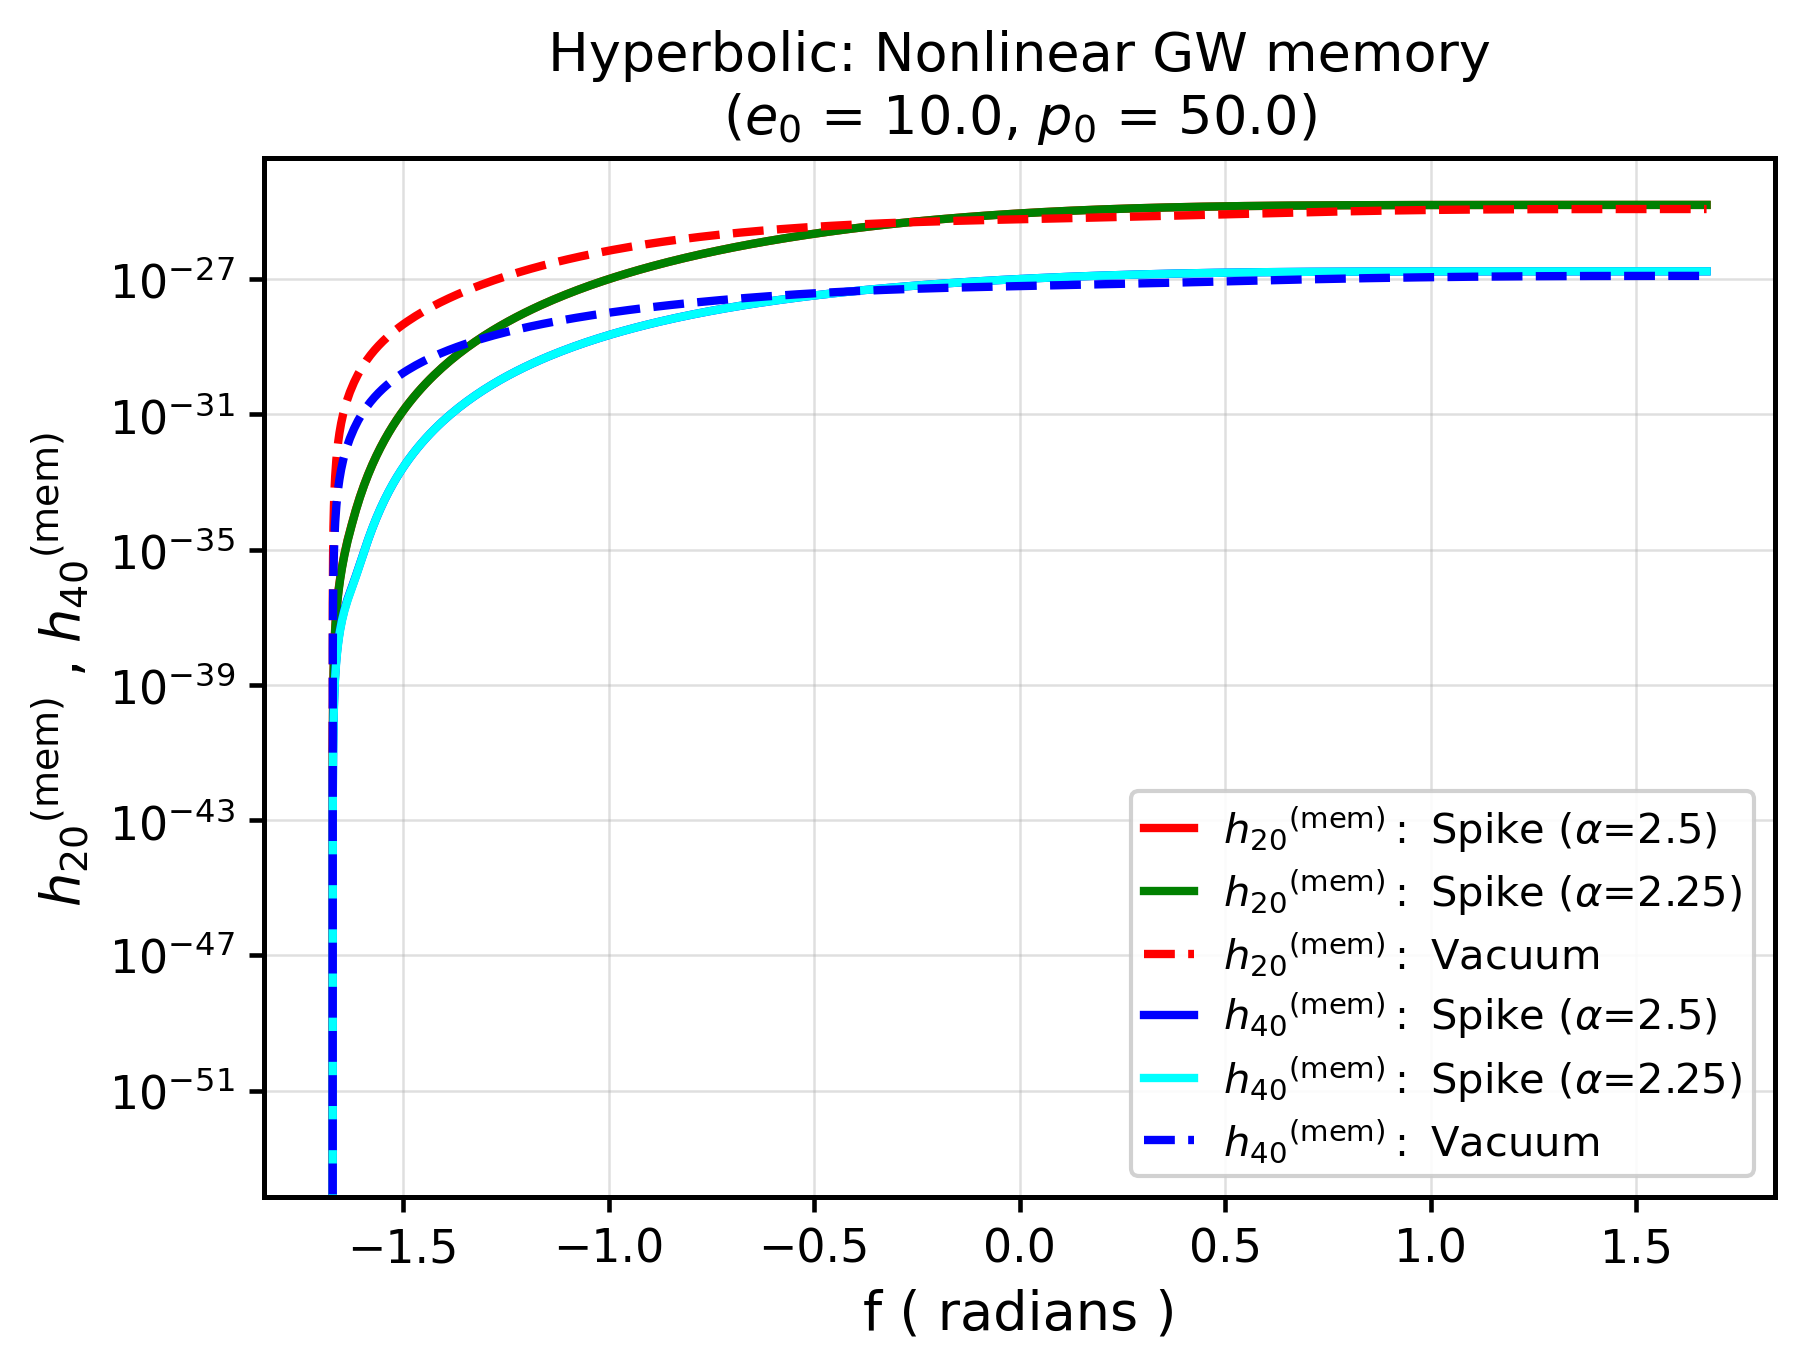

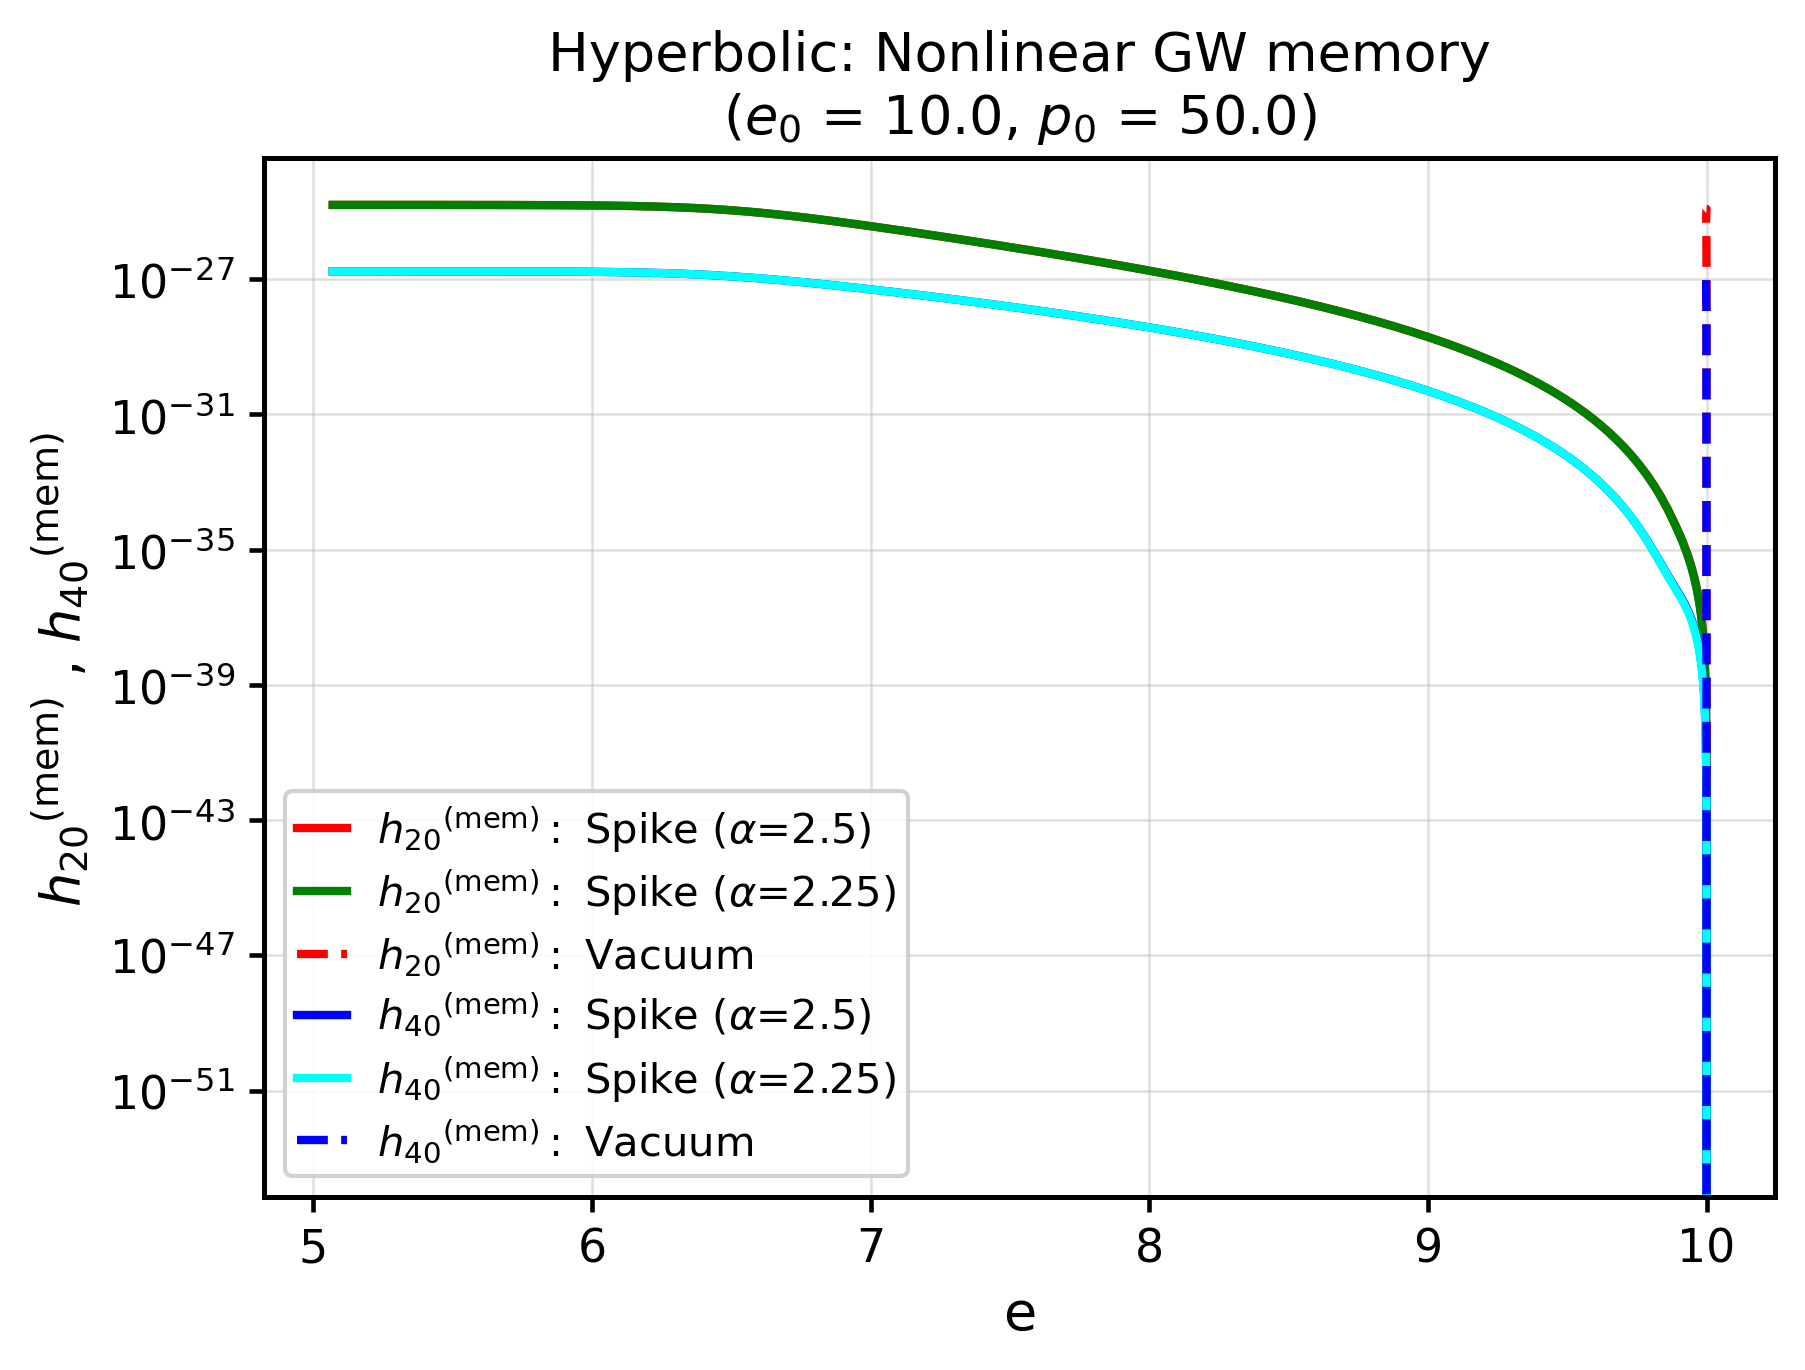

In [31]:
def hyperbolic_nonlinear_memo_diff_DM_exponent_vals(e_0, p_0, omega_0, t_0, alpha_vals, R):
    #  Static DM exponent values
    alpha_1 = alpha_vals[0] 
    alpha_2 = alpha_vals[1]

    # Calculating Nonlinear GW memory for given initial orbital parameters
    hyperbolic_nonlinear_memory1 = hyperbolic_calculate_nonlinear_memory(e_0, p_0, omega_0, t_0, alpha_1, R)
    hyperbolic_nonlinear_memory2 = hyperbolic_calculate_nonlinear_memory(e_0, p_0, omega_0, t_0, alpha_2, R)
    
    # Only GW backreaction
    fgw, ygw, h20_mem_gw, h40_mem_gw, h22P_mem_gw, h22M_mem_gw = hyperbolic_nonlinear_memory1.cal_hl0(val=2.5, combination=0)
    
    # NET : DM gravity + Relativistic DF + Accretion + GW brxn
    f_net1, y_net1, h20_mem_NET1, h40_mem_NET1, h22P_mem_NET1, h22M_mem_NET1 = hyperbolic_nonlinear_memory1.cal_hl0(val=0, combination=3)
    f_net2, y_net2, h20_mem_NET2, h40_mem_NET2, h22P_mem_NET2, h22M_mem_NET2 = hyperbolic_nonlinear_memory2.cal_hl0(val=0, combination=3)

    # Plotting Nonlinear memory VS True anomaly
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_0}, '+f'$p_0$ = {p_0})')
    
    plt.plot( f_net1, h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_1})', linestyle='-', color='red' )
    plt.plot( f_net2, h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_2})', linestyle='-', color='green' )
    
    plt.plot( fgw, h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum', linestyle='--', color='red')
    
    plt.plot( f_net1, h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_1})', linestyle='-', color='blue' )
    plt.plot( f_net2, h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_2})', linestyle='-', color='cyan' )
    
    plt.plot( fgw, h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum', linestyle='--', color='blue')
    
    plt.xlabel('f ( radians )')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    plt.savefig("hyperbolic_spike_plot_10.pdf", format="pdf", bbox_inches="tight")

    plt.show()
        
    # Plotting Nonlinear memory VS eccentricity
    plt.figure()
    plt.title('Hyperbolic: Nonlinear GW memory' + "\n" + rf'($e_0$ = {e_0}, '+f'$p_0$ = {p_0})')
    
    plt.plot( y_net1[0,:], h20_mem_NET1, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_1})', linestyle='-', color='red' )
    plt.plot( y_net2[0,:], h20_mem_NET2, label = r' ${h_{20}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_2})', linestyle='-', color='green' )
    
    plt.plot( ygw[0,:], h20_mem_gw, label= r' ${h_{20}}^{\text{(mem)}}: $' + rf' Vacuum', linestyle='--', color='red')
  
    plt.plot( y_net1[0,:], h40_mem_NET1, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_1})', linestyle='-', color='blue' )
    plt.plot( y_net2[0,:], h40_mem_NET2, label = r' ${h_{40}}^{\text{(mem)}}:$' +rf' Spike ($\alpha$={alpha_2})', linestyle='-', color='cyan' )

    plt.plot( ygw[0,:], h40_mem_gw, label= r' ${h_{40}}^{\text{(mem)}}: $' + rf' Vacuum', linestyle='--', color='blue')
   
    plt.xlabel('e')
    plt.ylabel(r' ${h_{20}}^{\text{(mem)}}$ , ${h_{40}}^{\text{(mem)}}$')
    # plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)

    # Save as PDF
    # plt.savefig("hyperbolic_spike_plot_11.pdf", format="pdf", bbox_inches="tight")

    plt.show()
    
# Initial orbital parameters
e0, p0, t0 = 10.0, 50.0, 0.0
omega0 = round(np.arccos(-1/e0),2)

alpha_vals = [2.5, 2.25] # Static DM exponent values

# Plotting Nonlinear memory for three-different Static DM exponent values
hyperbolic_nonlinear_memo_diff_DM_exponent_vals(e0, p0, omega0, t0, alpha_vals, R)